# Importacion de librerias

In [1]:
import pandas as pd
from dotenv import dotenv_values
import requests
from io import BytesIO
import unicodedata
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu


#ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Mostrar todas la columnas de los DataFrame
pd.set_option("display.max_columns", None)  # mostrar todas las columnas

# Utilizar los datos desde github

In [3]:
config = dotenv_values(dotenv_path=".env")

In [4]:
url = config['DATA_FILE_PATH']

headers = {"Authorization": f"Bearer {config['GITHUB_TOKEN']}"}
r = requests.get(url, headers=headers, timeout=30)
r.raise_for_status()  # Check if the request was successful

xlsx_data = pd.read_excel(BytesIO(r.content), header=None, sheet_name=None, engine="openpyxl")

# Funciones varias

In [5]:
# Limpiar cada hoja eliminando filas completamente vacías y restableciendo el índice
cleaned_sheets = {}
for name, sheet in xlsx_data.items():
    sheet = sheet.dropna(how="all")
    sheet = sheet.reset_index(drop=True)
    cleaned_sheets[name] = sheet

In [6]:
#Funcion para limpiar los nombres de las columnas y dejarlas mas estandarizadas
def clean_value(cadena):
  #Se eliminan espacios, se pasan a minusculas, se reemplazan espacios por guiones bajos, se eliminan acentos y caracteres especiales
  cadena = str(cadena).strip().lower().replace(' ', '_').replace('-','').replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u").replace(".","").replace("(","").replace(")","")
  return cadena

In [7]:
# funcion para detectar el formato de la tabla basándose en palabras clave en columnas específicas
def detect_table_format(sheet, keywords=['espacio'], check_columns=[0, 1]):
    """
    Detecta el formato de la tabla basándose en palabras clave en columnas específicas.
    
    Parámetros:
    - sheet: DataFrame a analizar
    - keywords: lista de palabras clave a buscar
    - check_columns: índices de columnas a verificar (0=primera columna, 1=segunda columna)
    
    Retorna:
    - 0 si la palabra clave se encuentra en la primera columna
    - 1 si la palabra clave se encuentra en la segunda columna
    - 'no determinada' si no se encuentra en ninguna
    """
    
    for col_idx in check_columns:
        if col_idx < len(sheet.columns):
            # Vectorizar la búsqueda: convierte a string y se limpia la columna de una sola vez
            col_data = sheet.iloc[:, col_idx].astype(str).str.lower().str.strip()
            
            # Aplicar transformaciones necesarias vectorizadas
            col_data_clean = col_data.str.replace(' ', '_', regex=False)
            col_data_clean = col_data_clean.str.replace('[áéíóú]', 
                lambda m: {'á':'a', 'é':'e', 'í':'i', 'ó':'o', 'ú':'u'}.get(m.group(0), m.group(0)), 
                regex=True)
            col_data_clean = col_data_clean.str.replace(r'[\-\.\(\)]', '', regex=True)
            
            # Verificar si alguna palabra clave existe en la columna
            pattern = '|'.join(keywords)
            if col_data_clean.str.contains(pattern, na=False, case=False).any():
                return col_idx
    
    return 'no determinada'

In [8]:
#Funcion para extraer la clasificación DC y edad del nombre de la hoja
def extract_patient_info(sheet_name):
    """Extrae la clasificación DC y edad del nombre de la hoja"""
    if 'F06' in str(sheet_name).upper():
        #Deterioro cognitivo leve
        dc = 1
    elif 'F02' in str(sheet_name).upper():
        #Demencia
        dc = 2
    elif 'GC' in str(sheet_name).upper():
        #Grupo de control
        dc = 0
    else: 
        dc = 'No determinada'
    
    age = str(sheet_name).split('-')[-1].strip()
    return dc, age

In [9]:
#funcion para extraer los valores de features de una tabla
def extract_features_from_table(sheet, headers_col, value_col, features, headers_clean=None):
    """
    Extrae los valores de features de una tabla.
    
    Parámetros:
    - sheet: DataFrame de la tabla
    - headers_col: índice de la columna con headers
    - value_col: índice de la columna con valores
    - features: lista de features a buscar
    - headers_clean: diccionario precominado de headers limpios
    
    Retorna: diccionario con los valores encontrados
    """
    # Pre-procesar headers para limpiarlos
    if headers_clean is None:
        headers = sheet.iloc[:, headers_col].astype(str)
        headers_clean = headers.apply(clean_value)
    else:
        headers_clean = headers_clean
    
    result = {}
    
    # Crear un diccionario para búsqueda rápida: feature_clean -> índice de fila
    feature_to_idx = {}
    for feature in features:
        mask = headers_clean.str.contains(feature, case=False, na=False)
        if mask.any():
            feature_to_idx[feature] = headers_clean[mask].index[0]
    
    # Extraer los valores para cada feature
    for feature in features:
        if feature in feature_to_idx:
            idx = feature_to_idx[feature]
            result[feature] = sheet.iloc[idx, value_col]
        else:
            result[feature] = None
    
    return result

In [10]:
# Función principal para buscar y extraer los valores de features de todas las tablas
def search_values(data, features, type_of_table):
    """
    Busca y extrae los valores de features de todas las tablas,
    diferenciando entre tabla formato 0 y formato 1.
    """
    # Configuración de parámetros para cada formato de tabla
    table_configs = {
        0: {'headers_col': 0, 'value_col': 3, 'nivel_estudio': 0},
        1: {'headers_col': 1, 'value_col': 4, 'nivel_estudio': 1}
    }
    
    results = []
    
    # Procesar todas las hojas
    for sheet_name, sheet in data.items():
        table_format = type_of_table[sheet_name]
        
        # Ignorar si el formato no se pudo determinar
        if table_format == 'no determinada':
            continue
        
        config = table_configs[table_format]
        
        # Extraer información del paciente
        dc, age = extract_patient_info(sheet_name)
        
        # Pre-procesar headers una sola vez para esta tabla
        headers = sheet.iloc[:, config['headers_col']].astype(str)
        headers_clean = headers.apply(clean_value)
        
        # Extraer features
        features_dict = extract_features_from_table(
            sheet, 
            config['headers_col'], 
            config['value_col'], 
            features,
            headers_clean
        )
        
        # Construir registro del paciente
        patient_data = {
            'sheet_name': sheet_name,
            'nivel_estudio': config['nivel_estudio'],
            'dc': dc,
            'age': age,
            **features_dict
        }
        
        results.append(patient_data)
    
    # Convertir a DataFrame
    dataset_final = pd.DataFrame(results)
    return dataset_final

# Lectura de datos

### Mapeo de columnas para los dos formatos de tablas

In [11]:
features = [
    
   #Tabla formato 0 -> Escolaridad baja
   #Tabla formato 1 -> Escolaridad alta
    
  #####Orientación
  
  #tabla 0 y tabla 1 con estos nombre ambos quedan en la misma columna
  'tiempo',
  'persona',
  'espacio', 
  
  #####Capacidad atencional

  #tabla 0
  'atencion_sostenida_auditiva', # -> 'digitos_en_progresion',
  'atencion_sostenida_visual', #Sin equivalencia
  'atencion_selectiva_visual', #Sin equivalencia
  'atencion_dividida_visual', # -> deteccion_visual
  #tabla 1
  'digitos_en_progresion',
#   'cubos_progresion',
  'deteccion_visual',
#   'deteccion_digitos_total',
  'series_sucesivas',

  #####Lenguaje
  
  #tabla 0
  'denominacion',
  'comprension_de_ordenes', #No crucial
  'material_verbal_complejo', #No crucial
  
  #tabla 1
  # 'denominacion'
  'semejanzas',
  # 'material_verbal_complejo',
  'comprension_de_ordenes',

  #####California verbal learning test | aprendizaje verbal del rey | memoria verbal
  
  #verbal del rey 
  
  #Tabla 0 - california verbal learning test
  'evocacion_inmediata_lista_a',
  'recuerdo_inmediato_lista_a',
  'recuerdo_inmediato_lista_b',
  'recuerdo_libre_a_corto_plazo',
  'recuerdo_libre_a_largo_plazo',
  'recuerdo_libre_a_largo_plazo',
  'reconocimiento',
  #tabla 0 - aprendizaje verbal del rey
  'evocacion_inmediata_lista_a',
  'recuerdo_inmediato_lista_b',
  'recuerdo_libre_a_corto_plazo',
  'recuerdo_libre_a_largo_plazo',
  'reconocimiento',
  #Tabla 1 #No tiene equivalencia con los otros test de la tabla 0
  'curva_de_memoria_volumen_promedio', 
  'memoria_verbal_espontanea_total',
  'memoria_verbal_claves_total',
  'memoria_verbal_reconocimiento',
  'memoria_lógica_promedio_historias',
  'memoria_lógica_promedio_historias',

  #####Memoria visual
  
  #Tabla 0
  'evocacion_diferida', # -> evocacion_figura_semicompleja
  #Tabla 1
  'caras_codificación',
  'reconocimiento_caras',
  'evocacion_figura_semicompleja',

  #####Genosias | capacidad visuoperceptiva
  #tabla 0
  'imagenes_sobrepuestas', # -> figuras_sobrepuestas
  'matrices',
  #tabla 1
  'imagenes_sobrepuestas',
  

  #####Praxis | praxias
  
  #Tabla 0
  'constructiva', #-> copia_de_figura_compleja
#   'ideomotora_gestos_simbolicos_a_la_orden_derecha',
#   'ideomotora_gestos_simbolicos_a_la_orden_izquierda',
#   'ideomotora_gestos_simbolicos_a_la_imitacion_derecha',
#   'ideomotora_gestos_simbolicos_a_la_imitacion_izquierda',
  #Tabla 1
  'copia_de_figura',
  'gestos_simbolicos',
  'imitacion_de_posturas',

  #####Funciones ejecutivas
  
  #Tabla 0
  'memoria_de_trabajo_digitos_inversos', # -> retencion_digitos_regresion
  'memoria_de_trabajo_digitos_secuenciales', # -> no tiene equivalencia
#   'test_de_fluidez_fonologica_fas_f',
#   'test_de_fluidez_fonologica_fas_a',
#   'test_de_fluidez_fonologica_fas_s',
  'fluidez_verbal_semantica',
  'semejanzas',
  'matrices',
  'comprension_abstraccion', # -> comprension_abstraccion
#   'atencion_alternante',
#   'stroop_a',
#   'stroop_b',
#   'stroop_c',
  'stroop_palabra',
  'stroop_color',
  'stroop_interferencia', # -> stroop_interferencia
  #tabla 1
  'semejanzas', # se puede presentar aqui o en lenguaje
  'fluidez_verbal_semantica',
  'fluidez_verbal_fonologica',
  'fluidez_no_verbal',
  'retencion_digitos_regresion'
  ]

### Mapeo de columas para la tabla con formato 0

In [12]:
features_tabla_0 = [
    
   #Tabla 0 nivel de estudio: Escolaridad baja
   #Tabla 1 nivel de estudio: Escolaridad alta
    
  #####Orientación
  
  #tabla 0 y tabla 1 con estos nombre ambos quedan en la misma columna
  'tiempo',
  'persona',
  'espacio', 
  
  #####Capacidad atencional

  #tabla 0
  'atencion_sostenida_auditiva', #'digitos_en_progresion',
  'atencion_sostenida_visual', #no tiene equivalencia
  'atencion_selectiva_visual', #no tiene equivalencia
  'atencion_dividida_visual', #Deteccion visual

  #####Lenguaje
  
  #tabla 0
  'denominacion',
  'material_verbal_complejo', #Es posible que no sea crucial
  'comprension_de_ordenes',

  #####California verbal learning test | aprendizaje verbal del rey | memoria verbal
  
  #verbal del rey 
  
  #Tabla 0 - california verbal learning test
  'evocacion_inmediata_lista_a',
  'recuerdo_inmediato_lista_a',
  'recuerdo_inmediato_lista_b',
  'recuerdo_libre_a_corto_plazo',
  'recuerdo_libre_a_largo_plazo',
  'recuerdo_libre_a_largo_plazo',
  'reconocimiento',
  #tabla 0 - aprendizaje verbal del rey
  'evocacion_inmediata_lista_a',
  'recuerdo_inmediato_lista_b',
  'recuerdo_libre_a_corto_plazo',
  'recuerdo_libre_a_largo_plazo',
  'reconocimiento',


  #####Memoria visual
  
  #Tabla 0
  'evocacion_diferida',#evocacion_figura_semicompleja

  #####Genosias | capacidad visuoperceptiva
  
  #tabla 0
  'imagenes_sobrepuestas',
  'matrices',

  #####Praxis | praxias
  
  #Tabla 0
  'copia_de_figura', #copia_de_figura_compleja
#   'ideomotora_gestos_simbolicos_a_la_orden_derecha',
#   'ideomotora_gestos_simbolicos_a_la_orden_izquierda',
#   'ideomotora_gestos_simbolicos_a_la_imitacion_derecha',
#   'ideomotora_gestos_simbolicos_a_la_imitacion_izquierda',

  #####Funciones ejecutivas
  
  #Tabla 0
  'memoria_de_trabajo_digitos_inversos', #retencion_digitos_regresion
  'memoria_de_trabajo_digitos_secuenciales', #no tiene equivalencia
#   'test_de_fluidez_fonologica_fas_f',
#   'test_de_fluidez_fonologica_fas_a',
#   'test_de_fluidez_fonologica_fas_s',
  'fluidez_verbal_semantica',
  'semejanzas',
  'matrices',
  'comprension_abstraccion', #comprension_abstraccion
#   'atencion_alternante',
#   'stroop_a',
#   'stroop_b',
#   'stroop_c',
  'stroop_palabra',
  'stroop_color',
  'stroop_interferencia', #stroop_interferencia
  ]

### Mapeo de columnas para la tabla con formato 1

In [13]:
features_tabla_1 = [
    
   #Tabla 0 nivel de estudio: Escolaridad baja
   #Tabla 1 nivel de estudio: Escolaridad alta
    
  #####Orientación
  
  #tabla 0 y tabla 1 con estos nombre ambos quedan en la misma columna
  'tiempo',
  'persona',
  'espacio', 
  
  #####Capacidad atencional

  #tabla 1
  'digitos_en_progresion',
#   'cubos_progresion',
  'deteccion_visual',
#   'deteccion_digitos_total',
  'series_sucesivas',

  #####Lenguaje
  

  # #tabla 1
  'denominacion',
  'semejanzas',
  'material_verbal_complejo',
  'comprension_de_ordenes',

  #####California verbal learning test | aprendizaje verbal del rey | memoria verbal
  
  #verbal del rey 
  
  #Tabla 1 #No tiene equivalencia con los otros test de la tabla 0
  'curva_de_memoria_volumen_promedio', 
  'memoria_verbal_espontanea_total',
  'memoria_verbal_claves_total',
  'memoria_verbal_reconocimiento',
  'memoria_logica_promedio_historias',

  #####Memoria visual
  
  #Tabla 1
  'caras_codificacion',
  'reconocimiento_caras',
  'evocacion_figura_semicompleja',

  #####Genosias | capacidad visuoperceptiva
  
  # tabla 1
  'imagenes_sobrepuestas',

  #####Praxis | praxias

  #Tabla 1
  'copia_de_figura',
  'gestos_simbolicos',

  #####Funciones ejecutivas

  #tabla 1
  'semejanzas', # se puede presentar aqui o en lenguaje
  'fluidez_verbal_semantica',
  'fluidez_verbal_fonologica',
  'fluidez_no_verbal',
  'retencion_digitos_regresion',
  ]

### Mapeo de columnas con las dos tablas en conjunto

In [14]:
features_tablas = [
    
   #Tabla 0 nivel de estudio: Escolaridad baja
   #Tabla 1 nivel de estudio: Escolaridad alta
    
  #####Orientación
  
  #tabla 0 y tabla 1 con estos nombre ambos quedan en la misma columna
  'tiempo',
  'persona',
  'espacio', 
  
  #####Capacidad atencional

  #tabla 0
  'atencion_sostenida_auditiva', #'digitos_en_progresion',
  'atencion_dividida_visual', #deteccion_visual
  #tabla 1
  'digitos_en_progresion',
  'deteccion_visual',

  #####Lenguaje
  
  #tabla 0
  'denominacion',
  'material_verbal_complejo',
  'semejanzas',
  # #tabla 1
  # 'denominacion'
#   'semejanzas'

  #####California verbal learning test | aprendizaje verbal del rey | memoria verbal
  
  #####Memoria visual
  
  #Tabla 0
  'evocacion_diferida',#evocacion_figura_semicompleja
  #Tabla 1
  'evocacion_figura_semicompleja',

  #####Genosias | capacidad visuoperceptiva
  # Las genosias se quedarian sin analizar

  #####Praxis | praxias
  
  #Tabla 0
  'constructiva', #copia_de_figura_compleja
  #Tabla 1
  'copia_de_figura_compleja',

  #####Funciones ejecutivas
  
  #Tabla 0
  'memoria_de_trabajo_digitos_inversos', #retencion_digitos_regresion
  'comprension_abstraccion', #comprension_abstraccion
  'comprension',
  #tabla 1
  'retencion_digitos_regresion',
  ]

### Hojas procesadas

In [15]:
print(f'Cantidad de datos {len(cleaned_sheets)} \n')
print(f'Nombre de las hojas procesadas:\n ')
sheets = list()
for name, sheet in cleaned_sheets.items():
    sheets.append(name)
print(sheets)

Cantidad de datos 125 

Nombre de las hojas procesadas:
 
['S1-F067-58', 'GC1-60', 'GC2-62', 'F021-72', 'S2-F067-53', 'GC3-60', 'S3-F067-66', 'GC4-72', 'GC5-62', 'S4-F067-66', 'GC6-69', 'GC7-70', 'F022-71', 'GC8-79', 'S5-F067-73', 'F023-87', 'F024-72', 'S6-F067-65', 'F025-82', 'GC8-80', 'GC9-66', 'GC10-65', 'F026-92', 'S7-F067-76', 'S8-F067-75', 'F027-79', 'GC11-72', 'S9-F067-66', 'S10-F067-65', 'GC12-65', 'S11-F067-84', 'F028-70', 's12-f067-77', 'S13-F067-77', 'F029-62', 'S14-F067-69', 'F0210-77', 'F0211-79', 'S15-F067-74', 'F0212-65', 'GC13-74', 'S16-F067-60', 'GC14-67', 'F0213-85', 'S17-F067-76', 'S18-F067-72', 'F0214-73', 'S19-F064-74', 'S20-F067-57', 'S21-F067-68', 'S22-F067-86', 'GC15-64', 'S23-F067-66', 'S24-F067-96', 'GC16-76', 'F0215-73', 'S25-F067-80', 'F0216-83', 'F0217-88', 'F0218-77', 'S26-F067-81', 'S27-F067-66', 'S28-F067-65', 'S29-F067-82', 'F0219-74', 'S30-F067-87', 'S31-F067-83', 'S32-F067-60', 'S33-F067-57', 'F0220-77', 'F0221-57', 'S34-F067-71', 'F0222-64', 'S35-F06

### Formatos de tablas

In [16]:
print('Formato de tabla 1:')
cleaned_sheets['S1-F067-58']

Formato de tabla 1:


,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alto: 14 a 19 puntos,NaN,Alto: 80 a 95 puntos
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Promedio: 7 a13 puntos,NaN,Promedio: 30 a 70 puntos
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alteración leve- moderado: 4 a 6 puntos,NaN,Bajo: 10 a 20 puntos
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alteración severa: 1 a 3 puntos,NaN,Déficit: <5 puntos
4,Dominio-Neuropsi Atención y Memoria- Test de B...,NaN,Puntuación obtenida,Puntuación normalizada,Interpretación,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Orientación,Tiempo,2/4 p,1,Alteración severa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Espacio,1/2 p,1,Alteración severa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Persona,1/1 p,11,Promedio,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Atención y concentración,Dígitos en progresión,3/9 p,3,Alteración severa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Detección visual total *2 comisiones*,9,6,Alteración Leve,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print('Formato de tabla 0:')
cleaned_sheets['GC4-72']

Formato de tabla 0:


,0,1,2,3
0,FUNCIÓN EVALUADA (TEST EMPLEADO),P. Directa,Percentil o P. Directa,Clasificación
1,Orientación,NaN,NaN,NaN
2,Orientación en persona (TB),7 de 7,95,Alto
3,Orientación en espacio (TB),5 de 5,95,Alto
4,Orientación en tiempo (TB),20 de 23,5,Bajo
5,Capacidad atencional y velocidad de procesamiento,NaN,NaN,NaN
6,Atención sostenida auditiva (Dígitos directos ...,6/16 p,8,Promedio
7,Atención sostenida visual (TMT-A),32 sg,95,Alto
8,Atención selectiva visual (Búsqueda de símbolos),29,13,Promedio
9,Atención dividida visual (Clave de números-WAIS),42,11,Promedio


In [18]:
# Aplicar la detección a todas las hojas de manera vectorizada
type_of_table = {name: detect_table_format(sheet) for name, sheet in cleaned_sheets.items()}
print(f'Cantidad de datos formato tabla 0: {list(type_of_table.values()).count(0)}')
print(f'Cantidad de datos formato tabla 1: {list(type_of_table.values()).count(1)}')
# print(f'Cantidad de datos con formato no determinado: {list(type_of_table.values()).count("no determinada")}')
print(f'Cantidad total de datos procesados: {len(type_of_table)}')

Cantidad de datos formato tabla 0: 36
Cantidad de datos formato tabla 1: 81
Cantidad total de datos procesados: 125


# Creación de los datasets

In [19]:
# Los dos formatos de tablas en conjunto
df_tablas = search_values(cleaned_sheets, features_tablas, type_of_table)

# Formato de tabla 0
cleaned_sheets_tabla_0 = {name: sheet for name, sheet in cleaned_sheets.items() if type_of_table[name] == 0}
df_tabla_0 = search_values(cleaned_sheets_tabla_0, features_tabla_0, type_of_table)

# Formato de tabla 1
cleaned_sheets_tabla_1 = {name: sheet for name, sheet in cleaned_sheets.items() if type_of_table[name] == 1}
df_tabla_1 = search_values(cleaned_sheets_tabla_1, features_tabla_1, type_of_table)

In [20]:
print(f'Grupo de control: {len(df_tablas[df_tablas["dc"] == 0])} personas')
print(f'Grupo de deterioro cognitivo: {len(df_tablas[df_tablas["dc"] == 1])} personas')
print(f'Grupo con demencia: {len(df_tablas[df_tablas["dc"] == 2])} personas')
print(f'Cantidad total de personas en el dataset: {len(df_tablas)} personas')

Grupo de control: 27 personas
Grupo de deterioro cognitivo: 58 personas
Grupo con demencia: 32 personas
Cantidad total de personas en el dataset: 117 personas


### Samples

In [21]:
df_tabla_1.sample(5)

,sheet_name,nivel_estudio,dc,age,tiempo,persona,espacio,digitos_en_progresion,deteccion_visual,series_sucesivas,denominacion,semejanzas,material_verbal_complejo,comprension_de_ordenes,curva_de_memoria_volumen_promedio,memoria_verbal_espontanea_total,memoria_verbal_claves_total,memoria_verbal_reconocimiento,memoria_logica_promedio_historias,caras_codificacion,reconocimiento_caras,evocacion_figura_semicompleja,imagenes_sobrepuestas,copia_de_figura,gestos_simbolicos,fluidez_verbal_semantica,fluidez_verbal_fonologica,fluidez_no_verbal,retencion_digitos_regresion
8,GC9-66,1,0,66,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Alto,Alto,Déficit,None,Promedio,Promedio,Alteración Leve,Promedio,Promedio,Promedio,Promedio,Promedio,Alto,Promedio,None,Promedio,Promedio,Promedio,Promedio
60,S39-F067-74,1,1,74,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Alto,Bajo,Alto,None,None,None,None,None,Alteración leve,Promedio,Promedio,Alteración leve,None,Promedio,None,Promedio,Promedio,Alteración leve,Promedio
57,F0224-81,1,2,81,Alteración severa,Promedio,Promedio,Promedio,Alteración severa,Promedio,Alto,Promedio,Alto,Alto,Alteración leve,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Alteración leve,Alteración leve,Alteración severa,None,Alteración leve,Promedio,Alteración severa,Promedio
9,GC10-65,1,0,65,Promedio,Promedio,Promedio,Promedio,Alto,Promedio,Alto,Alto,Alto,None,Alto,Alto,Alto,Alto,Alto,Promedio,Promedio,Promedio,Alto,Promedio,None,Alto,Alto,Alteración severa,Promedio
11,S7-F067-76,1,1,76,Alteración severa,Promedio,Promedio,Alteración leve,Alteración leve,Promedio,Déficit,Déficit,Déficit,None,Alteración leve,Promedio,Promedio,Promedio,Alteración leve,Promedio,Promedio,Alteración leve,Alto,Alteración severa,Alto,Alteración leve,Alteración leve,Alteración leve,Alteración leve


In [22]:
df_tabla_0.sample(5)

,sheet_name,nivel_estudio,dc,age,tiempo,persona,espacio,atencion_sostenida_auditiva,atencion_sostenida_visual,atencion_selectiva_visual,atencion_dividida_visual,denominacion,material_verbal_complejo,comprension_de_ordenes,evocacion_inmediata_lista_a,recuerdo_inmediato_lista_a,recuerdo_inmediato_lista_b,recuerdo_libre_a_corto_plazo,recuerdo_libre_a_largo_plazo,reconocimiento,evocacion_diferida,imagenes_sobrepuestas,matrices,copia_de_figura,memoria_de_trabajo_digitos_inversos,memoria_de_trabajo_digitos_secuenciales,fluidez_verbal_semantica,semejanzas,comprension_abstraccion,stroop_palabra,stroop_color,stroop_interferencia
15,S34-F067-71,0,1,71,Alto,Alto,Alto,Promedio,Alto,Promedio,Promedio,Alto,Alto,Alto,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,None,None,Alto,Promedio,Promedio,None,Promedio,Bajo,Promedio,Promedio,Promedio
29,S53-F067-54,0,1,54,Alto,Alto,Alto,Bajo,Promedio,Bajo,Bajo,None,Alto,Alto,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Promedio,None,Bajo,Promedio,Bajo,Bajo,Bajo,Bajo,Déficit,None,None,None
16,F0222-64,0,2,64,Bajo,Alto,Bajo,Bajo,Bajo,Bajo,Bajo,Alto,Alto,Alto,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,None,Bajo,Promedio,Bajo,None,Bajo,Bajo,Bajo,Bajo,Bajo
35,S57-F067-55,0,1,55,Alto,Alto,Alto,Promedio,Promedio,Promedio,Promedio,Alto,Alto,Alto,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Promedio,None,None,Promedio,Promedio,Promedio,None,Bajo,Bajo,Bajo,Bajo,Bajo
27,S51-F067-73,0,1,73,Alto,Alto,Alto,Promedio,Promedio,Promedio,Promedio,Alto,Promedio,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Bajo,Alto,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio,Promedio


In [23]:
df_tablas.sample(5)

,sheet_name,nivel_estudio,dc,age,tiempo,persona,espacio,atencion_sostenida_auditiva,atencion_dividida_visual,digitos_en_progresion,deteccion_visual,denominacion,material_verbal_complejo,semejanzas,evocacion_diferida,evocacion_figura_semicompleja,constructiva,copia_de_figura_compleja,memoria_de_trabajo_digitos_inversos,comprension_abstraccion,comprension,retencion_digitos_regresion
59,F0218-77,1,2,77,Alteración severa,Promedio,Promedio,None,None,Promedio,Promedio,Alto,Alto,Promedio,None,Alteración leve,None,Alteración severa,None,None,Promedio,Alteración leve
1,GC1-60,0,0,60,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None
32,s12-f067-77,1,1,77,Promedio,Promedio,Promedio,None,None,Promedio,Promedio,Alto,None,Promedio,None,Alteración Leve,None,None,None,Alto,Alto,Alteración Leve
111,S59-F067-84,1,1,84,Promedio,Promedio,Promedio,None,None,Alto,Promedio,Alto,None,Promedio,None,Promedio,None,None,None,None,None,Alteración Leve
72,S35-F067-67,0,1,67,Alto,Alto,Alto,Promedio,Promedio,None,None,Alto,Promedio,Promedio,Promedio,None,None,Promedio,Promedio,Alto,Déficit,None


### Corrección de nombre y rellenado de nulos

In [24]:
df_tablas['atencion_sostenida_auditiva'] = df_tablas['atencion_sostenida_auditiva'].fillna(df_tablas['digitos_en_progresion'])
df_tablas['atencion_dividida_visual'] = df_tablas['atencion_dividida_visual'].fillna(df_tablas['deteccion_visual'])
df_tablas['evocacion_diferida'] = df_tablas['evocacion_diferida'].fillna(df_tablas['evocacion_figura_semicompleja'])
df_tablas['constructiva'] = df_tablas['constructiva'].fillna(df_tablas['copia_de_figura_compleja'])
df_tablas['memoria_de_trabajo_digitos_inversos'] = df_tablas['memoria_de_trabajo_digitos_inversos'].fillna(df_tablas['retencion_digitos_regresion'])
df_tablas['comprension_abstraccion'] = df_tablas['comprension_abstraccion'].fillna(df_tablas['comprension'])



df_tablas.drop(columns=['digitos_en_progresion'], inplace=True)
df_tablas.drop(columns=['deteccion_visual'], inplace=True)
df_tablas.drop(columns=['evocacion_figura_semicompleja'], inplace=True)
df_tablas.drop(columns=['copia_de_figura_compleja'], inplace=True)
df_tablas.drop(columns=['retencion_digitos_regresion'], inplace=True)
df_tablas.drop(columns=['comprension'], inplace=True)

# atencion_sostenida_auditiva->digitos_en_progresion o
# atencion_dividida_visual->deteccion_visual o
# evocacion_diferida->evocacion_figura_semicompleja o
# constructiva->copia_de_figura_compleja o
# memoria_de_trabajo_digitos_inversos->retencion_digitos_regresion o

# Normalización de datos

In [25]:
# Función para limpiar tildes
def limpiar_tildes(texto):
    texto_nfd = unicodedata.normalize('NFD', str(texto))
    return ''.join(c for c in texto_nfd if unicodedata.category(c) != 'Mn')

def limpiar_caracteres_especiales(texto):
    # Eliminar caracteres especiales excepto espacios y guiones bajos y guiones
    return ''.join(c for c in str(texto) if c.isalnum() or c in [' ', '_', '-'])

def limpiar_texto(texto):
    if pd.isna(texto) or texto == 'None' or texto == 'nan':
        return None
    
    # LUEGO aplicar las limpiezas
    texto = str(texto)
    texto = limpiar_tildes(texto)
    texto = limpiar_caracteres_especiales(texto)
    texto = texto.lower().strip()
    
    return texto if texto else None

### Tabla 0

In [26]:
#Alteracion severa - 1,2,3
#bajo - 4,5,6
#promedio - 7-13
#Alto - 14-18

In [27]:
# Reemplazo de valores
for col in df_tabla_1.columns:
    # Aplicar limpieza de tildes antes de hacer los reemplazos
    df_tabla_1[col] = df_tabla_1[col].apply(limpiar_texto)
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion severa', 'alteracion_severa')
    df_tabla_1[col] = df_tabla_1[col].replace('altearcion severa', 'alteracion_severa')
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion leve', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion moderada', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('aleracion leve', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('deficit', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion leve-moderada', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('alteracion leve-moderada', 'bajo')
    df_tabla_1[col] = df_tabla_1[col].replace('alto', 'alto')
    df_tabla_1[col] = df_tabla_1[col].replace('promedio', 'promedio')
    df_tabla_1[col] = df_tabla_1[col].replace('normal alto', 'alto')
    df_tabla_1[col] = df_tabla_1[col].replace('maximo', 'alto')

In [28]:
#mostrar los posibles valores de todas las columnas menos dc, age, nivel_estudio, sheet_name

cols = df_tabla_1.columns.difference(['dc', 'age', 'nivel_estudio', 'sheet_name'])
for col in cols:
    print(f'Valores únicos en la columna "{col}": {df_tabla_1[col].unique()}')

Valores únicos en la columna "caras_codificacion": ['promedio' None 'alto' 'alteracion_severa']
Valores únicos en la columna "comprension_de_ordenes": ['bajo' None 'alto' 'promedio']
Valores únicos en la columna "copia_de_figura": ['promedio' 'alteracion_severa' 'alto' None 'bajo']
Valores únicos en la columna "curva_de_memoria_volumen_promedio": ['promedio' 'bajo' 'alto' 'alteracion_severa' None]
Valores únicos en la columna "denominacion": ['alto' 'bajo' 'promedio' None]
Valores únicos en la columna "deteccion_visual": ['bajo' 'promedio' 'alteracion_severa' 'alto' None]
Valores únicos en la columna "digitos_en_progresion": ['alteracion_severa' 'promedio' 'bajo' None 'alto']
Valores únicos en la columna "espacio": ['alteracion_severa' 'promedio' None]
Valores únicos en la columna "evocacion_figura_semicompleja": ['promedio' 'bajo' 'alteracion_severa' None 'alto']
Valores únicos en la columna "fluidez_no_verbal": ['promedio' 'bajo' 'alteracion_severa' 'alto' None]
Valores únicos en la 

### Tabla 1

In [29]:
#tabla 1
# menor a 5 alteracion Alteración Severa
# 5 a 24 bajo   
# 25 a 85 promedio
# 85 a 100 Alto

In [30]:
# Reemplazo de valores
for col in df_tabla_0.columns:
    # Aplicar limpieza de tildes antes de hacer los reemplazos
    df_tabla_0[col] = df_tabla_0[col].apply(limpiar_texto)
    df_tabla_0[col] = df_tabla_0[col].replace('alto', 'alto')
    df_tabla_0[col] = df_tabla_0[col].replace('deficit', 'alteracion_severa')
    df_tabla_0[col] = df_tabla_0[col].replace('promedio', 'promedio')
    df_tabla_0[col] = df_tabla_0[col].replace('bajo', 'bajo')
    df_tabla_0[col] = df_tabla_0[col].replace('maximo', 'alto')


In [31]:
#mostrar los posibles valores de todas las columnas menos dc, age, nivel_estudio, sheet_name

cols = df_tabla_0.columns.difference(['dc', 'age', 'nivel_estudio', 'sheet_name'])
for col in cols:
    print(f'Valores únicos en la columna "{col}": {df_tabla_0[col].unique()}')

Valores únicos en la columna "atencion_dividida_visual": [None 'promedio' 'bajo']
Valores únicos en la columna "atencion_selectiva_visual": [None 'promedio' 'bajo']
Valores únicos en la columna "atencion_sostenida_auditiva": [None 'promedio' 'bajo' 'alto']
Valores únicos en la columna "atencion_sostenida_visual": [None 'promedio' 'alteracion_severa' 'bajo' 'alto']
Valores únicos en la columna "comprension_abstraccion": [None 'promedio' 'alteracion_severa' 'alto' 'bajo']
Valores únicos en la columna "comprension_de_ordenes": [None 'alto' 'bajo' 'alteracion_severa']
Valores únicos en la columna "copia_de_figura": [None 'alto' 'alteracion_severa' 'bajo' 'promedio']
Valores únicos en la columna "denominacion": [None 'alto']
Valores únicos en la columna "espacio": [None 'alto' 'bajo']
Valores únicos en la columna "evocacion_diferida": [None 'promedio' 'bajo' 'alto' 'alteracion_severa']
Valores únicos en la columna "evocacion_inmediata_lista_a": [None 'promedio' 'bajo']
Valores únicos en la 

# Verificación de nulos

In [32]:
print(df_tabla_0.shape)
df_tabla_0.isna().sum()

(36, 32)


,0
sheet_name,0
nivel_estudio,0
dc,0
age,0
tiempo,1
persona,1
espacio,1
atencion_sostenida_auditiva,1
atencion_sostenida_visual,4
atencion_selectiva_visual,1


In [33]:
print(df_tabla_1.shape)
df_tabla_1.isna().sum()

(81, 29)


,0
sheet_name,0
nivel_estudio,0
dc,0
age,0
tiempo,3
persona,3
espacio,3
digitos_en_progresion,3
deteccion_visual,6
series_sucesivas,3


# Manejo de valores nulos

En datasets clinicos, los nulos no se tratan solo como ruido estadistico. Pueden reflejar fatiga del paciente, severidad del cuadro, o ausencia de una prueba por criterio clinico. Por eso el manejo debe:

1. **Conservar pacientes** (evitar eliminar filas).
2. **Modelar la ausencia** (indicadores de nulo por variable).
3. **Imputar por grupo diagnostico** (`dc`) para no borrar diferencias clinicas.
4. **Evitar imputar variables con demasiada ausencia** (mantener nulo e indicador).

Criterios propuestos:
- **< 5% nulos**: imputacion simple por mediana (numerico) o moda (categorico).
- **5-30% nulos**: imputacion por grupo `dc` + indicador de ausencia.
- **>= 30% nulos**: mantener nulo + indicador, revisar clinicamente.

El objetivo es conservar informacion clinica y minimizar sesgos.

In [34]:
# Funciones para perfilado e imputacion clinica de nulos
ID_COLS = ['dc', 'age', 'nivel_estudio', 'sheet_name']


def null_data_info(df, id_cols):
    cols = [c for c in df.columns if c not in id_cols] #Se omiten las columnas de identificación para el perfilado de nulos
    resumen = pd.DataFrame({
        'nulos': df[cols].isna().sum(),
        '%_nulos': (df[cols].isna().mean() * 100).round(2),
        'dtype': df[cols].dtypes.astype(str),
        'n_unicos': df[cols].nunique(dropna=True)
    }).sort_values('%_nulos', ascending=False)
    return resumen


def imputacion_null(df, id_cols, group_col='dc', high_missing=0.30):
    df_imp = df.copy()
    cols = [col for col in df.columns if col not in id_cols]
    missing_rate = df[cols].isna().mean() #El porcentaje de nulos por columna se calcula como el número de nulos dividido por el total de filas, lo que da un valor entre 0 y 1 representando el porcentaje de nulos en cada columna.

    for col in cols:
        porcent = missing_rate[col]
        if porcent == 0:
            continue

        # Indicador de ausencia
        df_imp[f'{col}_missing'] = df[col].isna().astype(int)

        # Si hay demasiados nulos, no imputar
        if porcent >= high_missing:
            continue

        # Imputacion por tipo de dato
        if df[col].dtype == 'object': #Si la columna es de tipo object, se asume que es categórica y se imputa con la moda por grupo clínico. La función fill_mode calcula la moda de cada grupo definido por group_col (en este caso, 'dc') y luego llena los valores nulos con esa moda. Si no hay una moda clara (es decir, si hay un empate), se toma el primer valor de la moda. Si aún quedan nulos después de esta imputación, se realiza una imputación global utilizando la moda de toda la columna.
            # Moda por grupo clinico
            def fill_mode(s):
                #Se calcula la moda de la serie s, omitiendo los valores nulos. Si hay una moda clara, se toma el primer valor; si no, se asigna NaN. Luego, se llena la serie s con este valor de moda para los valores nulos.
                mode = s.mode(dropna=True)
                fill_value = mode.iloc[0] if len(mode) > 0 else np.nan
                return s.fillna(fill_value)

            df_imp[col] = df.groupby(group_col)[col].transform(fill_mode)

            # Fallback global si aun quedan nulos despues de la imputacion por grupo clinico
            if df_imp[col].isna().any():
                global_mode = df[col].mode(dropna=True)
                if len(global_mode) > 0:
                    df_imp[col] = df_imp[col].fillna(global_mode.iloc[0])
        else:
            # Si la variable no es categórica, se asume que es numérica y se imputa con la mediana por grupo clínico. La función fill_median calcula la mediana de cada grupo definido por group_col (en este caso, 'dc') y luego llena los valores nulos con esa mediana. Si aún quedan nulos después de esta imputación, se realiza una imputación global utilizando la mediana de toda la columna.
            df_imp[col] = df.groupby(group_col)[col].transform(lambda s: s.fillna(s.median()))

            # Fallback global si aun quedan nulos
            if df_imp[col].isna().any():
                df_imp[col] = df_imp[col].fillna(df[col].median())

    return df_imp


# Perfil de nulos
print('=== PERFIL NULOS TABLA 0 ===')
perfil_t0 = null_data_info(df_tabla_0, ID_COLS)
print(perfil_t0[perfil_t0['nulos'] > 0])

print('\n=== PERFIL NULOS TABLA 1 ===')
perfil_t1 = null_data_info(df_tabla_1, ID_COLS)
print(perfil_t1[perfil_t1['nulos'] > 0])

# Imputacion clinica (sin eliminar pacientes)
df_tabla_0_imp = imputacion_null(df_tabla_0, ID_COLS)
df_tabla_1_imp = imputacion_null(df_tabla_1, ID_COLS)

print('\nTablas imputadas:')
print('df_tabla_0_imp ->', df_tabla_0_imp.shape)
print('df_tabla_1_imp ->', df_tabla_1_imp.shape)


=== PERFIL NULOS TABLA 0 ===
                                         nulos  %_nulos   dtype  n_unicos
fluidez_verbal_semantica                    23    63.89  object         4
matrices                                    12    33.33  object         4
imagenes_sobrepuestas                       11    30.56  object         3
stroop_interferencia                         9    25.00  object         4
material_verbal_complejo                     6    16.67  object         3
denominacion                                 5    13.89  object         1
stroop_palabra                               4    11.11  object         4
stroop_color                                 4    11.11  object         4
atencion_sostenida_visual                    4    11.11  object         4
evocacion_diferida                           4    11.11  object         4
memoria_de_trabajo_digitos_secuenciales      3     8.33  object         2
comprension_abstraccion                      3     8.33  object         4
semejanza

In [35]:
df_tabla_0[df_tabla_0['sheet_name'] == 's3-f067-66']

,sheet_name,nivel_estudio,dc,age,tiempo,persona,espacio,atencion_sostenida_auditiva,atencion_sostenida_visual,atencion_selectiva_visual,atencion_dividida_visual,denominacion,material_verbal_complejo,comprension_de_ordenes,evocacion_inmediata_lista_a,recuerdo_inmediato_lista_a,recuerdo_inmediato_lista_b,recuerdo_libre_a_corto_plazo,recuerdo_libre_a_largo_plazo,reconocimiento,evocacion_diferida,imagenes_sobrepuestas,matrices,copia_de_figura,memoria_de_trabajo_digitos_inversos,memoria_de_trabajo_digitos_secuenciales,fluidez_verbal_semantica,semejanzas,comprension_abstraccion,stroop_palabra,stroop_color,stroop_interferencia
5,s3-f067-66,0,1,66,alto,alto,alto,promedio,bajo,promedio,bajo,alto,bajo,alto,bajo,bajo,promedio,bajo,bajo,bajo,bajo,alto,None,None,promedio,None,promedio,promedio,promedio,bajo,bajo,None


# Creación de tabla conjunta

In [36]:
# Crear dataframe conjunto por dominios usando puntaje ordinal

def _to_ordinal(series):
    mapping = {
        'alteracion_severa': 1,
        'bajo': 2,
        'promedio': 3,
        'alto': 4
    }
    return series.map(mapping)


def _domain_score(df, cols):
    cols_present = [c for c in cols if c in df.columns]
    if not cols_present:
        return pd.Series([None] * len(df), index=df.index)
    scores = df[cols_present].apply(_to_ordinal)
    return scores.mean(axis=1)


# Unir las dos tablas imputadas
cols_id = ['sheet_name', 'nivel_estudio', 'dc', 'age']
df_union = pd.concat([df_tabla_0_imp, df_tabla_1_imp], ignore_index=True, sort=False)

# Definicion de dominios
dominios = {
    'orientacion': ['tiempo', 'persona', 'espacio'],
    'atencion': [
        'atencion_sostenida_auditiva',
        'atencion_sostenida_visual',
        'atencion_selectiva_visual',
        'atencion_dividida_visual',
        'digitos_en_progresion',
        'deteccion_visual',
        'series_sucesivas'
    ],
    'lenguaje': [
        'denominacion',
        'comprension_de_ordenes',
        'material_verbal_complejo',
        'semejanzas',
        'comprension_ejecucion_de_ordenes'
    ],
    'memoria_verbal': [
        'evocacion_inmediata_lista_a',
        'recuerdo_inmediato_lista_a',
        'recuerdo_inmediato_lista_b',
        'recuerdo_libre_a_corto_plazo',
        'recuerdo_libre_a_largo_plazo',
        'reconocimiento',
        'curva_de_memoria_volumen_promedio',
        'memoria_verbal_espontanea_total',
        'memoria_verbal_claves_total',
        'memoria_verbal_reconocimiento',
        'memoria_logica_promedio_historias'
    ],
    'memoria_visual': [
        'evocacion_diferida',
        'caras_codificacion',
        'reconocimiento_caras',
        'evocacion_figura_semicompleja'
    ],
    'gnosias': ['imagenes_sobrepuestas',
                'matrices'],
    'praxis': [
        'copia_de_figura',
        'gestos_simbolicos',
        'imitacion_de_posturas'
    ],
    'ejecutivas': [
        'memoria_de_trabajo_digitos_inversos',
        'memoria_de_trabajo_digitos_secuenciales',
        'evocacion_categorial_semantica',
        'matrices',
        'comprension_abstraccion',
        'stroop_palabra',
        'stroop_colores',
        'stroop_interferencia',
        'fluidez_verbal_semantica',
        'fluidez_verbal_fonologica',
        'fluidez_no_verbal',
        'retencion_digitos_regresion'
    ]
}

# Construir dataframe por dominios
df_complete = df_union[cols_id].copy()
for dominio, cols in dominios.items():
    df_complete[dominio] = _domain_score(df_union, cols)

In [37]:
df_complete.sample(20)

,sheet_name,nivel_estudio,dc,age,orientacion,atencion,lenguaje,memoria_verbal,memoria_visual,gnosias,praxis,ejecutivas
35,s57-f067-55,0,1,55,4.000000,3.000000,3.500000,2.000000,3.000000,NaN,3.0,2.400000
105,f0228-86,1,2,86,1.000000,2.333333,2.750000,3.000000,2.333333,2.0,2.5,1.250000
8,s4-f067-66,0,1,66,4.000000,3.000000,4.000000,2.000000,3.000000,NaN,3.0,2.800000
89,f0220-77,1,2,77,2.333333,2.666667,3.000000,2.500000,2.666667,4.0,2.5,2.500000
94,f0225-84,1,2,84,2.333333,3.000000,3.500000,2.400000,2.666667,4.0,4.0,2.500000
2,f021-72,0,2,72,4.000000,2.500000,4.000000,2.166667,2.000000,4.0,1.0,1.500000
16,f0222-64,0,2,64,2.666667,2.000000,3.500000,2.000000,2.000000,2.0,2.0,2.200000
68,s19-f064-74,1,1,74,3.000000,2.666667,3.333333,3.000000,2.666667,4.0,3.5,3.000000
78,f0216-83,1,2,83,3.000000,3.000000,3.750000,3.000000,2.666667,4.0,2.5,2.750000
62,s15-f067-74,1,1,74,3.000000,2.666667,3.500000,3.000000,2.666667,2.0,2.5,2.000000


In [38]:
df_complete.isnull().sum()

,0
sheet_name,0
nivel_estudio,0
dc,0
age,0
orientacion,0
atencion,0
lenguaje,0
memoria_verbal,0
memoria_visual,0
gnosias,7


In [39]:
#ver las columnas que tienen gnosias en nulo
df_complete[df_complete['gnosias'].isnull()][cols_id]

,sheet_name,nivel_estudio,dc,age
0,gc1-60,0,0,60
8,s4-f067-66,0,1,66
13,s16-f067-60,0,1,60
15,s34-f067-71,0,1,71
20,s46-f067-66,0,1,66
21,gc21-64,0,0,64
35,s57-f067-55,0,1,55


In [40]:
# Patron de nulos: resumen, por grupo clinico y co-ocurrencia

def patron_nulos(df, id_cols, group_col='dc'):
    cols = [c for c in df.columns if c not in id_cols]
    miss = df[cols].isna().astype(int)

    print('--- Resumen global ---')
    resumen = miss.mean().sort_values(ascending=False)
    print(resumen[resumen > 0])

    print('\n--- Nulos por grupo clinico (dc) ---')
    grupo = miss.groupby(df[group_col]).mean().sort_index()
    print(grupo)

    print('\n--- Nulos por paciente (distribucion) ---')
    nulos_paciente = miss.sum(axis=1)
    print(nulos_paciente.describe())

    print('\n--- Co-ocurrencia de nulos (top 10 pares) ---')
    corr = miss.corr()
    corr.values[[range(corr.shape[0])], [range(corr.shape[0])]] = 0
    pares = (
        corr.stack()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr_missing'})
    )
    print(pares.head(10))


print('=== PATRON DE NULOS TABLA 0 ===')
patron_nulos(df_tabla_0, ID_COLS)

print('\n=== PATRON DE NULOS TABLA 1 ===')
patron_nulos(df_tabla_1, ID_COLS)


=== PATRON DE NULOS TABLA 0 ===
--- Resumen global ---
fluidez_verbal_semantica                   0.638889
matrices                                   0.333333
imagenes_sobrepuestas                      0.305556
stroop_interferencia                       0.250000
material_verbal_complejo                   0.166667
denominacion                               0.138889
stroop_palabra                             0.111111
stroop_color                               0.111111
atencion_sostenida_visual                  0.111111
evocacion_diferida                         0.111111
memoria_de_trabajo_digitos_secuenciales    0.083333
comprension_abstraccion                    0.083333
semejanzas                                 0.083333
comprension_de_ordenes                     0.055556
copia_de_figura                            0.055556
reconocimiento                             0.055556
recuerdo_inmediato_lista_b                 0.055556
recuerdo_libre_a_corto_plazo               0.055556
recuerdo_

In [41]:
null_data_info(df_complete, ID_COLS)

,nulos,%_nulos,dtype,n_unicos
gnosias,7,5.98,float64,5
orientacion,0,0.00,float64,7
lenguaje,0,0.00,float64,13
atencion,0,0.00,float64,12
memoria_verbal,0,0.00,float64,19
memoria_visual,0,0.00,float64,9
praxis,0,0.00,float64,7
ejecutivas,0,0.00,float64,23


In [42]:
dominios = ['orientacion','atencion','lenguaje','memoria_verbal','memoria_visual','gnosias','praxis','ejecutivas']

#Perfil y patrones por grupo
perfil = df_complete[dominios].isna().mean().sort_values(ascending=False)
print(perfil)

# Imputacion por grupo clinico si nulos moderados
#Se imputan los valores de las praxias por mediana del grupo clinico debido a que el porcenaje es moderado esta por debajo del 1%
for col in dominios:
    if df_complete[col].isna().mean() < 0.30:
        df_complete[col] = df_complete.groupby('dc')[col].transform(lambda s: s.fillna(s.median()))

gnosias           0.059829
orientacion       0.000000
lenguaje          0.000000
atencion          0.000000
memoria_verbal    0.000000
memoria_visual    0.000000
praxis            0.000000
ejecutivas        0.000000
dtype: float64


In [ ]:
null_data_info(df_complete, ID_COLS)

In [43]:
df_complete

,sheet_name,nivel_estudio,dc,age,orientacion,atencion,lenguaje,memoria_verbal,memoria_visual,gnosias,praxis,ejecutivas
0,gc1-60,0,0,60,4.000000,3.250000,3.750000,2.666667,3.000000,3.5,4.0,3.200000
1,gc2-62,0,0,62,4.000000,3.000000,3.750000,2.500000,3.000000,3.5,4.0,3.000000
2,f021-72,0,2,72,4.000000,2.500000,4.000000,2.166667,2.000000,4.0,1.0,1.500000
3,s2-f067-53,0,1,53,4.000000,2.000000,3.000000,2.000000,3.000000,4.0,2.0,2.166667
4,gc3-60,0,0,60,4.000000,3.000000,3.500000,2.666667,3.000000,3.5,4.0,3.142857
...,...,...,...,...,...,...,...,...,...,...,...,...
112,s60-f067-72,1,1,72,3.000000,2.666667,3.333333,3.000000,3.000000,4.0,3.5,3.250000
113,s61-f067-75,1,1,75,2.333333,2.000000,3.000000,3.250000,2.666667,4.0,3.5,2.500000
114,f0233-85,1,2,85,1.000000,2.000000,3.000000,2.750000,2.666667,4.0,2.5,1.500000
115,gc29-65,1,0,65,3.000000,3.000000,3.666667,3.000000,2.666667,4.0,3.5,2.750000


In [44]:
null_data_info(df_complete, ID_COLS)

,nulos,%_nulos,dtype,n_unicos
orientacion,0,0.0,float64,7
atencion,0,0.0,float64,12
lenguaje,0,0.0,float64,13
memoria_verbal,0,0.0,float64,19
memoria_visual,0,0.0,float64,9
gnosias,0,0.0,float64,5
praxis,0,0.0,float64,7
ejecutivas,0,0.0,float64,23


In [45]:
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sheet_name      117 non-null    object 
 1   nivel_estudio   117 non-null    object 
 2   dc              117 non-null    object 
 3   age             117 non-null    object 
 4   orientacion     117 non-null    float64
 5   atencion        117 non-null    float64
 6   lenguaje        117 non-null    float64
 7   memoria_verbal  117 non-null    float64
 8   memoria_visual  117 non-null    float64
 9   gnosias         117 non-null    float64
 10  praxis          117 non-null    float64
 11  ejecutivas      117 non-null    float64
dtypes: float64(8), object(4)
memory usage: 11.1+ KB


In [46]:
df_complete["age_num"] = pd.to_numeric(df_complete["age"], errors="coerce")

In [47]:
df_complete.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sheet_name      117 non-null    object 
 1   nivel_estudio   117 non-null    object 
 2   dc              117 non-null    object 
 3   age             117 non-null    object 
 4   orientacion     117 non-null    float64
 5   atencion        117 non-null    float64
 6   lenguaje        117 non-null    float64
 7   memoria_verbal  117 non-null    float64
 8   memoria_visual  117 non-null    float64
 9   gnosias         117 non-null    float64
 10  praxis          117 non-null    float64
 11  ejecutivas      117 non-null    float64
 12  age_num         117 non-null    int64  
dtypes: float64(8), int64(1), object(4)
memory usage: 12.0+ KB


In [48]:
DC_LABELS  = {0: "Control", 1: "DCL", 2: "Demencia"} # Mapa de los niveles de deterioro cognitivos
DC_PALETTE = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"} #Paleta de colores para las gráficas
DC_ORDER   = [0, 1, 2] # Orden de la variable objetivo
EDUCATION_LEVEL = {
    '0': "Escolaridad Baja", 
    '1': "Escolaridad Alta"
}

#Dominios cognitivos a tener en cuenta
DOMINIOS = [
    "orientacion", "atencion", "lenguaje", "memoria_verbal",
    "memoria_visual", "gnosias", "praxis", "ejecutivas",
]

In [49]:
#Configuraciones para las gráficas
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110})

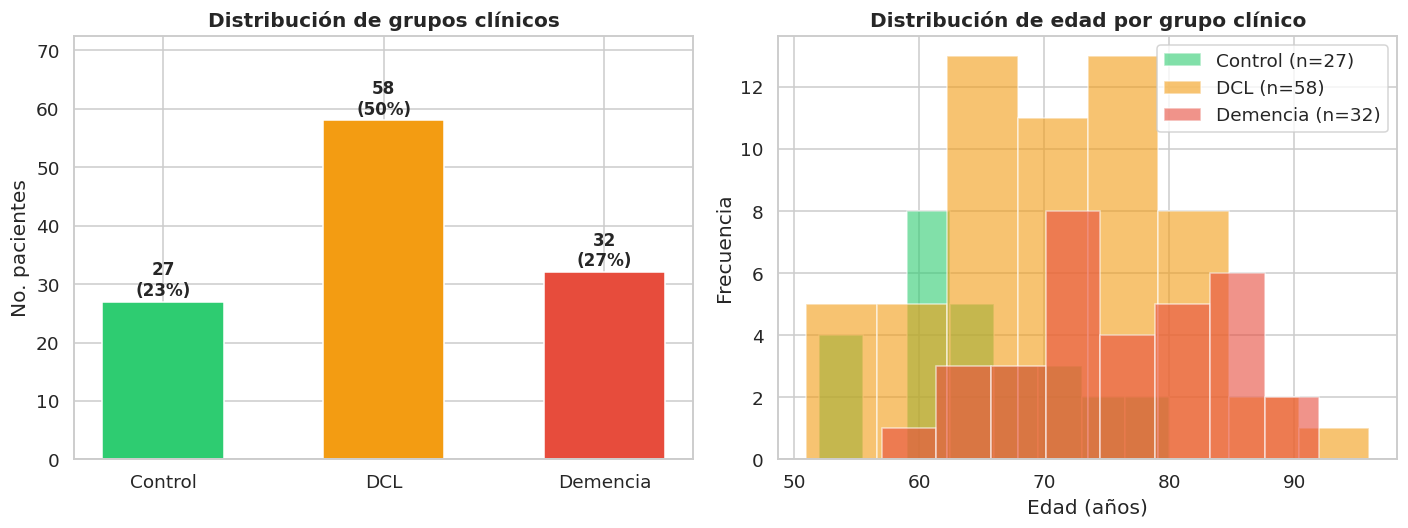


Edad por grupo
     n   media    std  min  max  dc_label
dc                                       
0   27  64.556  7.723   52   80   Control
1   58  70.603  9.514   51   96       DCL
2   32  76.219  8.435   57   92  Demencia


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# GRÁFICO DE DISTRIBUCIÓN DE LOS DATOS
counts = df_complete["dc"].value_counts().sort_index()
x_pos = list(range(len(DC_ORDER)))
bars = axes[0].bar(
    x_pos,
    [counts.get(k, 0) for k in DC_ORDER],
    color=[DC_PALETTE[k] for k in DC_ORDER],
    edgecolor="white", width=0.55,
)
for bar, k in zip(bars, DC_ORDER):
    v   = counts.get(k, 0)
    pct = v / len(df_complete) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{v}\n({pct:.0f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([DC_LABELS[k] for k in DC_ORDER])
axes[0].set_ylabel("No. pacientes")
axes[0].set_title("Distribución de grupos clínicos", fontweight="bold")
axes[0].set_ylim(0, counts.max() * 1.25)

# --- Gráfico 2: distribución de edad por grupo
for dc_val in DC_ORDER:
    subset = df_complete[df_complete["dc"] == f'{dc_val}']["age_num"].dropna()
    axes[1].hist(subset, bins=8, alpha=0.6, color=DC_PALETTE[dc_val], label=f"{DC_LABELS[dc_val]} (n={len(subset)})", edgecolor="white")
axes[1].set_xlabel("Edad (años)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de edad por grupo clínico", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabla de estadísticos de edad
print("\nEdad por grupo")
print(
    df_complete.groupby("dc")["age_num"]
    .agg(n="count", media="mean", std="std", min="min", max="max")
    .assign(dc_label=lambda x: x.index.astype(int).map(DC_LABELS))
    .round(3)
)


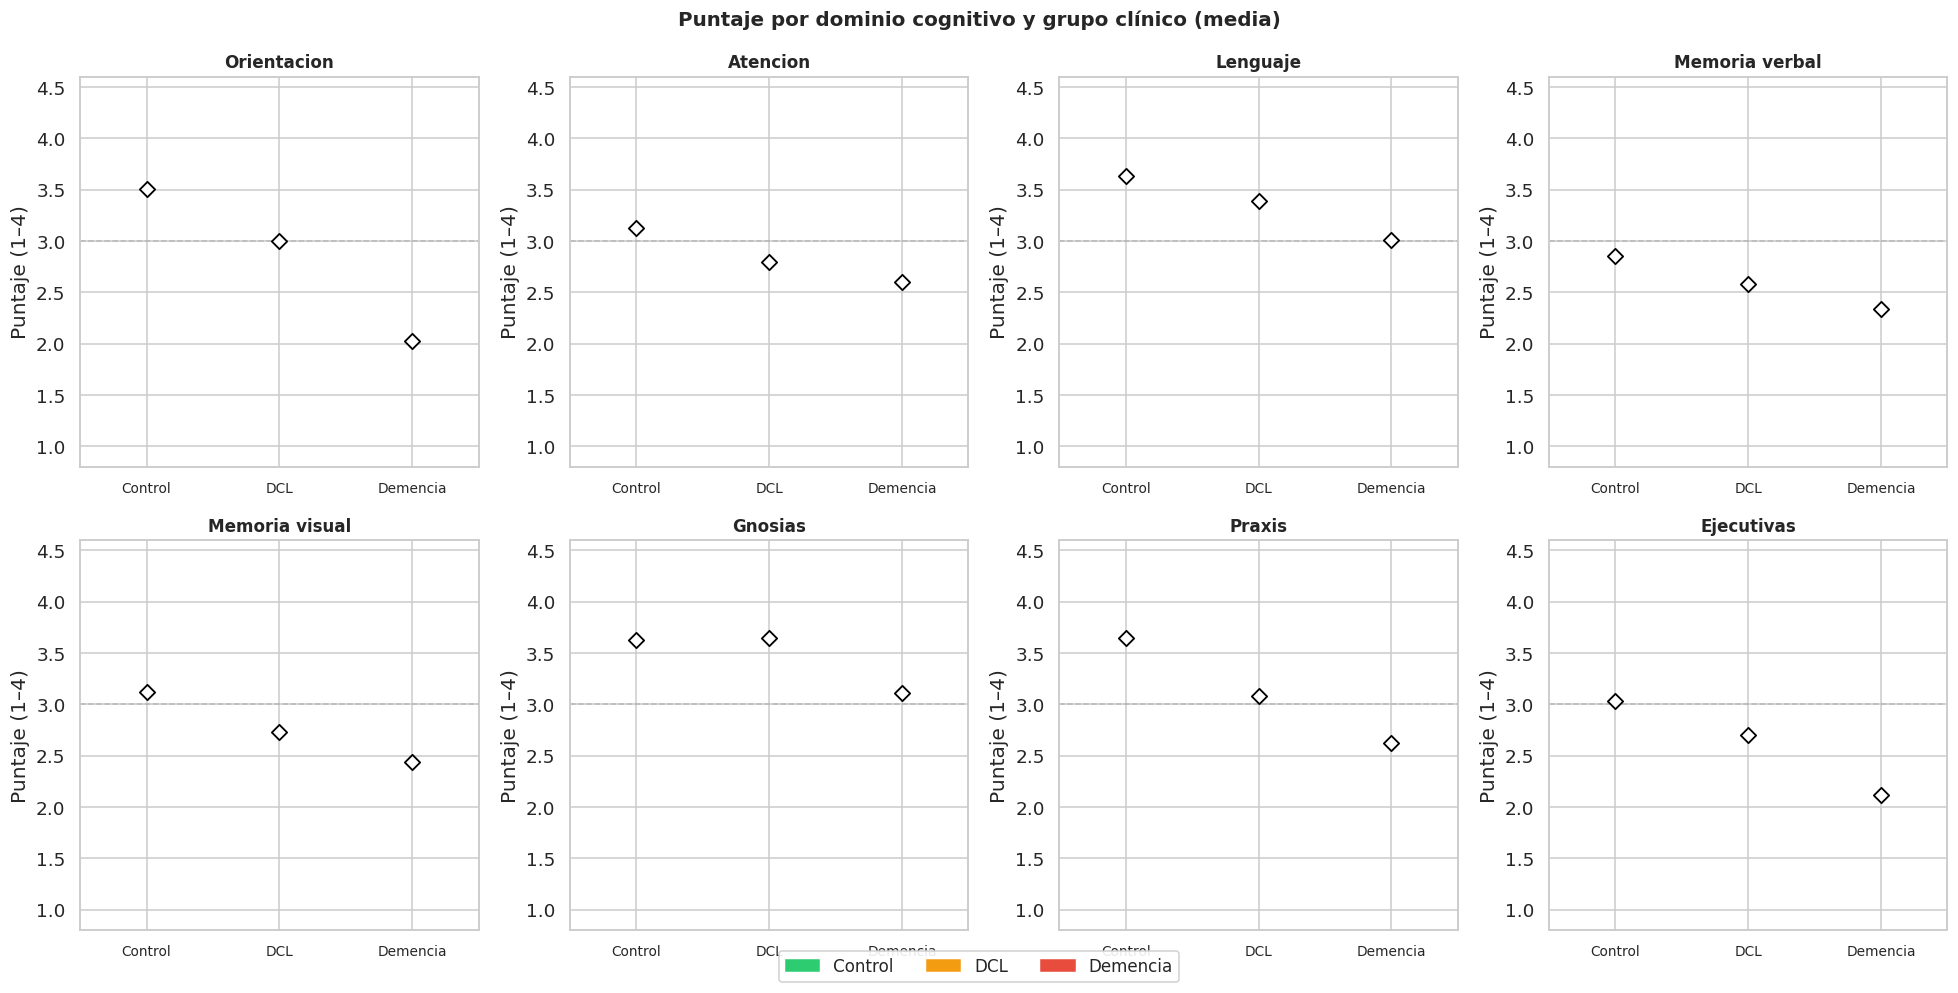

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), squeeze=False)
axes_flat = axes.flatten()

for ax, dominio in zip(axes_flat, DOMINIOS):
    data_plot = [
        df_complete[df_complete["dc"] == dc_val][dominio] for dc_val in DC_ORDER
    ]

    bp = ax.boxplot(
        data_plot,
        patch_artist=True,
        notch=False,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=5, alpha=0.5),
    )
    for patch, dc_val in zip(bp["boxes"], DC_ORDER):
        patch.set_facecolor(DC_PALETTE[dc_val])
        patch.set_alpha(0.75)

    # Media como diamante
    for i, dc_val in enumerate(DC_ORDER, 1):
        vals = df_complete[df_complete["dc"] == f'{dc_val}'][dominio].dropna()
        if len(vals) > 0:
            ax.scatter(i, vals.mean(), marker="D", s=50,
                       color="white", edgecolors="black",
                       linewidth=1.2, zorder=5)

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([DC_LABELS[k] for k in DC_ORDER], fontsize=9)
    ax.set_ylabel("Puntaje (1–4)")
    ax.set_ylim(0.8, 4.6)
    ax.set_title(dominio.replace("_", " ").capitalize(),
                 fontweight="bold", fontsize=11)
    ax.axhline(3, color="grey", linestyle="--", alpha=0.35, linewidth=1)

handles = [mpatches.Patch(color=DC_PALETTE[k], label=DC_LABELS[k])
           for k in DC_ORDER]
fig.legend(handles=handles, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.01), fontsize=11, framealpha=0.9)
fig.suptitle(
    "Puntaje por dominio cognitivo y grupo clínico (media)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

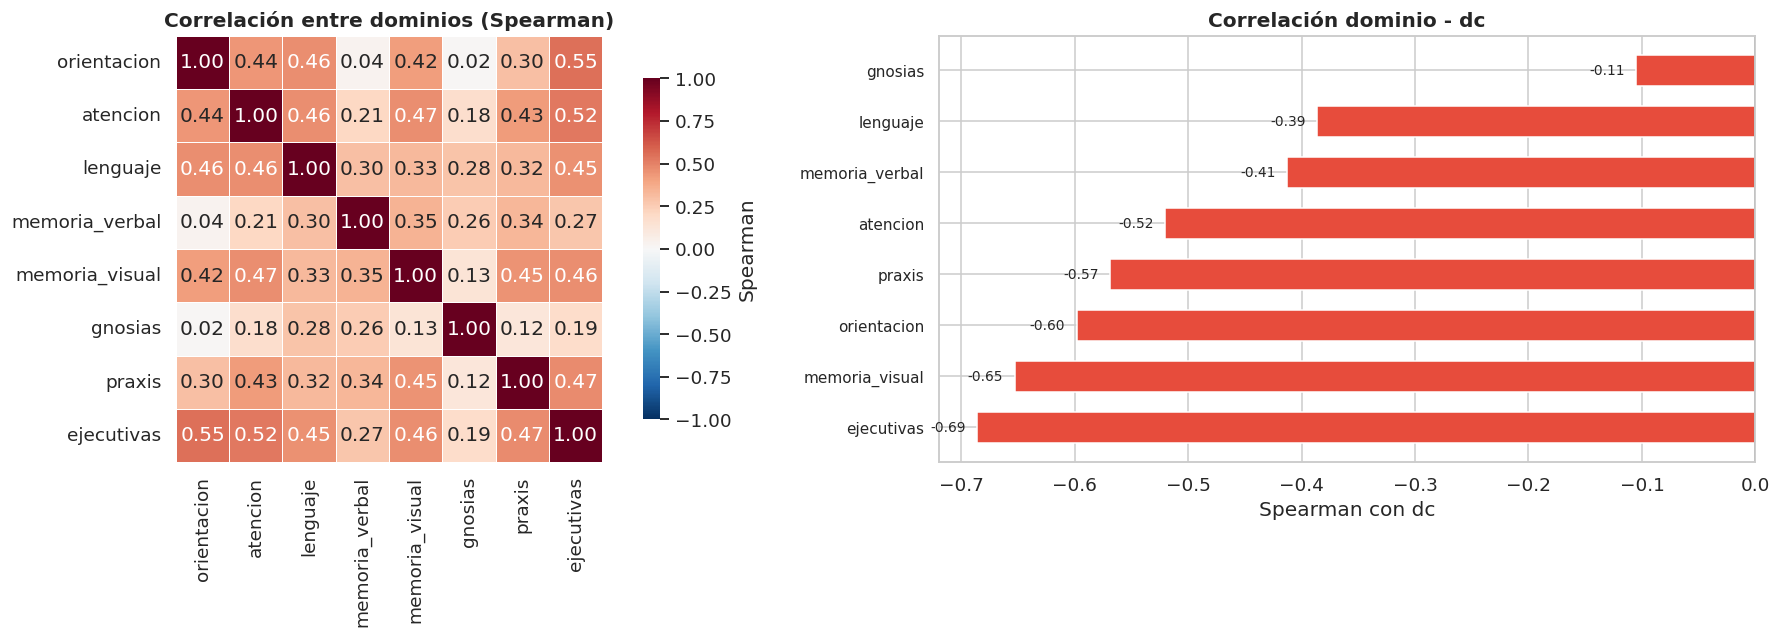

In [52]:
#Gráficos de correlaciones

fig, axes = plt.subplots(1, 2, figsize=(18, 6), squeeze=False)
ax_left, ax_right = axes[0, 0], axes[0, 1]

# Heatmap entre dominios
corr_dom = df_complete[DOMINIOS].corr(method="spearman")
sns.heatmap(
    corr_dom, ax=ax_left,
    annot=True, fmt=".2f",
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Spearman"},
)
ax_left.set_title("Correlación entre dominios (Spearman)", fontweight="bold")

# Gráfico de Spearmna correlación dominio vs dc
corr_dc = (
    df_complete[DOMINIOS + ["dc"]]
    .corr(method="spearman")[["dc"]]
    .drop("dc")
    .sort_values("dc")
)
dom_names = corr_dc.index.tolist()
rho_vals  = corr_dc["dc"].values.tolist()
y_pos     = list(range(len(dom_names)))
bar_colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in rho_vals]

ax_right.barh(y_pos, rho_vals, color=bar_colors, edgecolor="white", height=0.6)
ax_right.set_yticks(y_pos)
ax_right.set_yticklabels(dom_names, fontsize=10)
ax_right.axvline(0, color="black", linewidth=1.2)
ax_right.set_xlabel("Spearman con dc")
ax_right.set_title("Correlación dominio - dc",
                   fontweight="bold")
for i, v in enumerate(rho_vals):
    offset = 0.01 if v >= 0 else -0.01
    ha     = "left" if v >= 0 else "right"
    ax_right.text(v + offset, i, f"{v:.2f}", va="center", ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

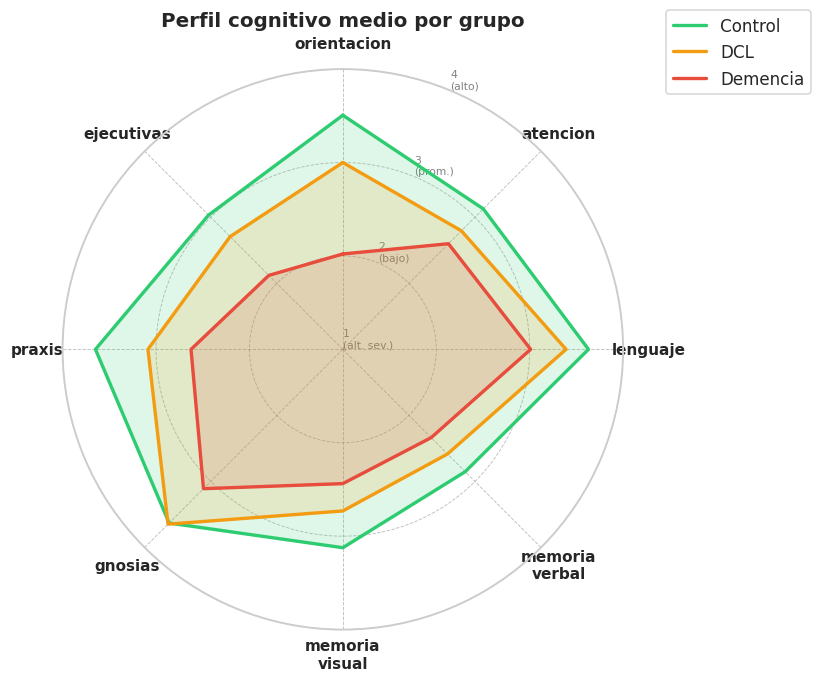

In [53]:
#Gráfico de distribuciones por dominio en grupos
N = len(DOMINIOS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + angles[:1] 
labels = [d.replace("_", "\n") for d in DOMINIOS]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for dc_val in DC_ORDER:
    vals = df_complete[df_complete["dc"] == f'{dc_val}'][DOMINIOS].mean().values
    v_closed = vals.tolist() + [vals[0]]
    ax.plot(angles_closed, v_closed,
            color=DC_PALETTE[dc_val], linewidth=2.2, label=DC_LABELS[dc_val])
    ax.fill(angles_closed, v_closed,
            color=DC_PALETTE[dc_val], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles)
ax.set_xticklabels(labels, fontsize=10, fontweight="bold")
ax.set_ylim(1, 4)
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1\n(alt. sev.)", "2\n(bajo)", "3\n(prom.)", "4\n(alto)"],
                   fontsize=7, color="grey")
ax.grid(color="grey", linestyle="--", linewidth=0.6, alpha=0.5)
ax.set_title("Perfil cognitivo medio por grupo",
             fontsize=13, fontweight="bold", pad=28)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=11)
plt.tight_layout()
plt.show()

1. ¿Qué representa el eje X (-log10(p-value))?
En estadística, los valores p (p-values) que indican diferencias muy fuertes suelen ser números muy pequeños (como 0.001 o 0.00004). Graficar valores tan pequeños directamente es difícil. Por eso, tu código aplica una transformación matemática: el logaritmo base 10 negativo (-log10). Al hacer esto, la interpretación se invierte y se vuelve más intuitiva:

Un p-valor grande (no significativo, ej. p = 0.5) se convierte en una barra muy pequeña.
Un p-valor pequeño (muy significativo, ej. p = 0.001) se convierte en una barra muy larga.
En resumen: Entre más larga sea la barra hacia la derecha, más fuerte es la diferencia entre tus grupos (Control vs Leve vs Demencia) en ese dominio cognitivo.
2. La línea punteada negra (thresh = -np.log10(0.05))
Tu código dibuja una línea vertical negra en el valor 1.301 (que es el equivalente matemático de p = 0.05).

Esa línea es la "frontera del éxito".
Cualquier dominio (barra) que cruce esa línea hacia la derecha, significa que pasó la prueba y tiene diferencias estadísticas reales y comprobables.
3. Los colores (Rojo y Gris)
🔴 Barras Rojas (#e74c3c): Son los dominios donde Kruskal-Wallis encontró que al menos uno de tus grupos es diferente de los demás (p < 0.05). Son los dominios que logran sobrepasar la línea negra.
⚪ Barras Grises (#95a5a6): Son los dominios donde NO se encontraron diferencias estadísticas entre los pacientes. Los grupos en esos dominios tuvieron puntajes estadísticamente iguales.
¿Qué te dice esta gráfica sobre tus datos?
De un solo vistazo, esta gráfica te responde a la pregunta: "¿En qué habilidades cognitivas (dominios) el estado de la enfermedad (Control, Deterioro Leve, Demencia) hace más mella?" El dominio cognitivo que tenga la barra roja más larga es aquel en el que los puntajes cambian de forma más radical y obvia dependiendo de si el paciente está sano, tiene deterioro leve, o demencia.

Kruskal-Wallis: diferencias entre grupos dc

Dominio                    H    p-value
---------------------------------------------
orientacion           42.835  0.0000000005
atencion              34.231  0.0000000369
lenguaje              17.310  0.0001742189
memoria_verbal        19.748  0.0000514965
memoria_visual        49.730  0.0000000000
gnosias                6.912  0.0315572940
praxis                38.236  0.0000000050
ejecutivas            54.880  0.0000000000


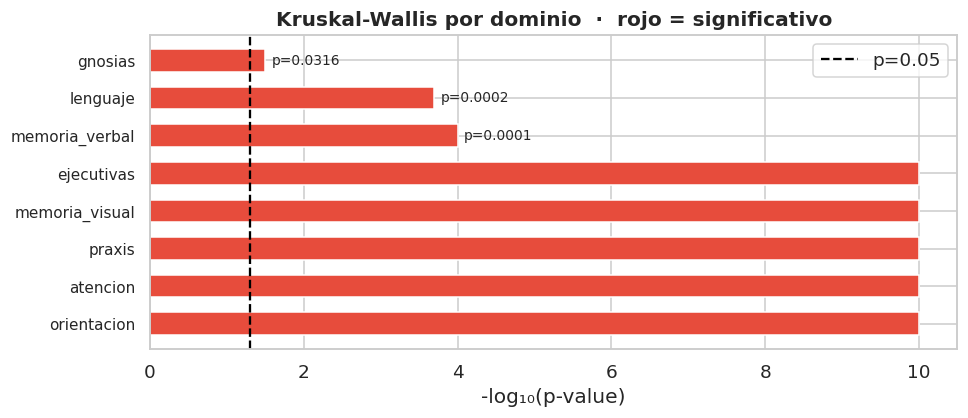

In [54]:
print("Kruskal-Wallis: diferencias entre grupos dc\n")
print(f"{'Dominio':<20} {'H':>7}  {'p-value':>9}")
print("-" * 45)

kw_rows = []
for dom in DOMINIOS:
    grupos = [
        df_complete[df_complete["dc"] == f'{k}'][dom] for k in DC_ORDER
    ]
    grupos_ok = [g for g in grupos if len(g) >= 2]
    if len(grupos_ok) < 2:
        kw_rows.append({"dominio": dom, "H": np.nan, "p": np.nan})
        continue
    H, p = kruskal(*grupos_ok)
    kw_rows.append({"dominio": dom, "H": round(H, 3), "p": round(p, 4)})
    print(f"{dom:<20} {H:>7.3f}  {p:>9.10f}")

# Gráfico de -log10(p)
df_kw = pd.DataFrame(kw_rows).sort_values("p").reset_index(drop=True)
n_kw = len(df_kw)
y_pos = list(range(n_kw))
c_kw = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in df_kw["p"]]
thresh = -np.log10(0.05)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(y_pos, -np.log10(df_kw["p"].clip(lower=1e-10)),
        color=c_kw, edgecolor="white", height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_kw["dominio"].tolist(), fontsize=10)
ax.axvline(thresh, color="black", linestyle="--", linewidth=1.5, label="p=0.05")
ax.set_xlabel("-log₁₀(p-value)")
ax.set_title("Kruskal-Wallis por dominio  ·  rojo = significativo",
             fontweight="bold")
ax.legend()

for i, row in df_kw.iterrows():
    x_val = -np.log10(row["p"])
    ax.text(x_val + 0.08, i, f"p={row['p']:.4f}",
            va="center", fontsize=9)

plt.tight_layout()
plt.show()

La Figura muestra los resultados de la prueba de Kruskal-Wallis utilizando la transformación −log
10
	​

(p), donde la línea punteada representa el nivel de significancia de p=0.05. Todos los dominios evaluados superan dicho umbral, indicando diferencias estadísticamente significativas entre los grupos. Los dominios de funciones ejecutivas, memoria visual, praxis, atención y orientación presentan la evidencia estadística más fuerte (p-values extremadamente pequeños), mientras que gnosias, aunque significativa (p=0.0316), muestra la menor evidencia relativa de diferencias entre los grupos. No obstante, esta representación refleja únicamente la significancia estadística y no la magnitud de las diferencias observadas.

In [55]:
print("=" * 70)
print("RESUMEN ESTADÍSTICO - df_complete por grupo clínico")
print("=" * 70)

rows = []
for dom in DOMINIOS:
    row = {"Dominio": dom}
    for k in DC_ORDER:
        vals = df_complete[df_complete["dc"] == f'{k}'][dom].dropna()
        lbl  = DC_LABELS[k]
        row[f"{lbl} n"]      = len(vals)
        row[f"{lbl} media"]  = round(vals.mean(), 2) if len(vals) else np.nan
        row[f"{lbl} mediana"]= round(vals.median(), 2) if len(vals) else np.nan
        row[f"{lbl} std"]    = round(vals.std(), 2) if len(vals) else np.nan
    rows.append(row)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print(pd.DataFrame(rows).set_index("Dominio").to_string())


RESUMEN ESTADÍSTICO - df_complete por grupo clínico
                Control n  Control media  Control mediana  Control std  DCL n  DCL media  DCL mediana  DCL std  Demencia n  Demencia media  Demencia mediana  Demencia std
Dominio                                                                                                                                                                   
orientacion            27           3.51             4.00         0.54     58       3.00         3.00     0.81          32            2.02              2.33          0.84
atencion               27           3.13             3.00         0.17     58       2.79         2.88     0.35          32            2.60              2.67          0.39
lenguaje               27           3.63             3.75         0.34     58       3.39         3.50     0.46          32            3.01              3.00          0.66
memoria_verbal         27           2.85             3.00         0.39     58       2.58     

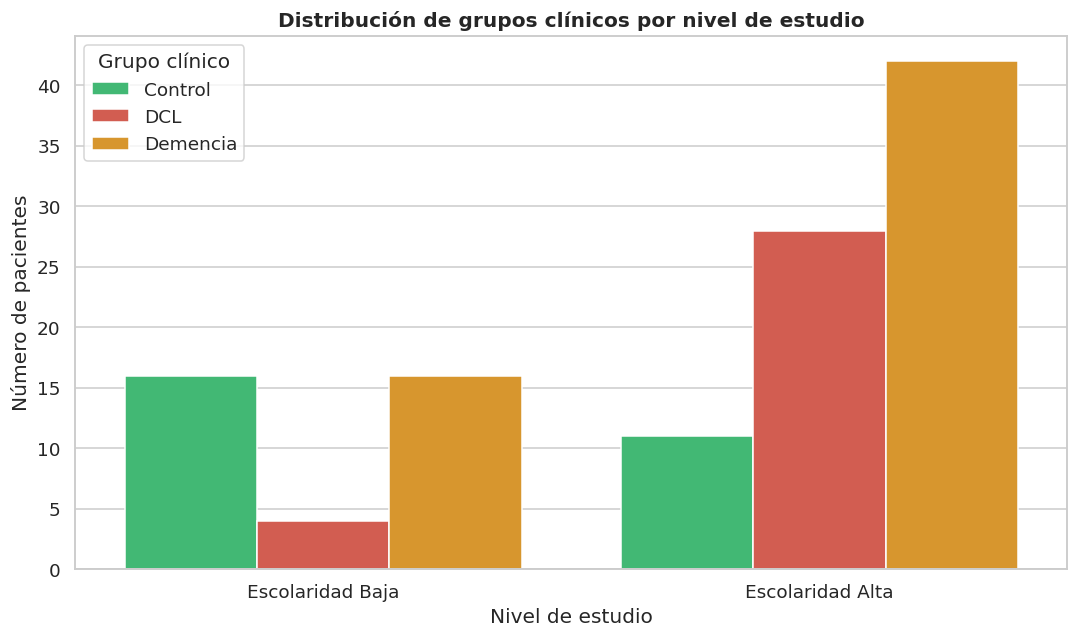

In [56]:
#gráfico comparativo de dc por estudio
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(
    data=df_complete.assign(nivel_estudio_texto=df_complete["nivel_estudio"].map(EDUCATION_LEVEL)), 
    x="nivel_estudio_texto", 
    hue="dc", 
    palette={str(k): v for k, v in DC_PALETTE.items()}, 
    ax=ax
)
ax.set_title("Distribución de grupos clínicos por nivel de estudio", fontweight="bold")
ax.set_xlabel("Nivel de estudio")
ax.set_ylabel("Número de pacientes")
ax.legend(title="Grupo clínico", labels=[DC_LABELS[k] for k in DC_ORDER])
plt.tight_layout()
plt.show()


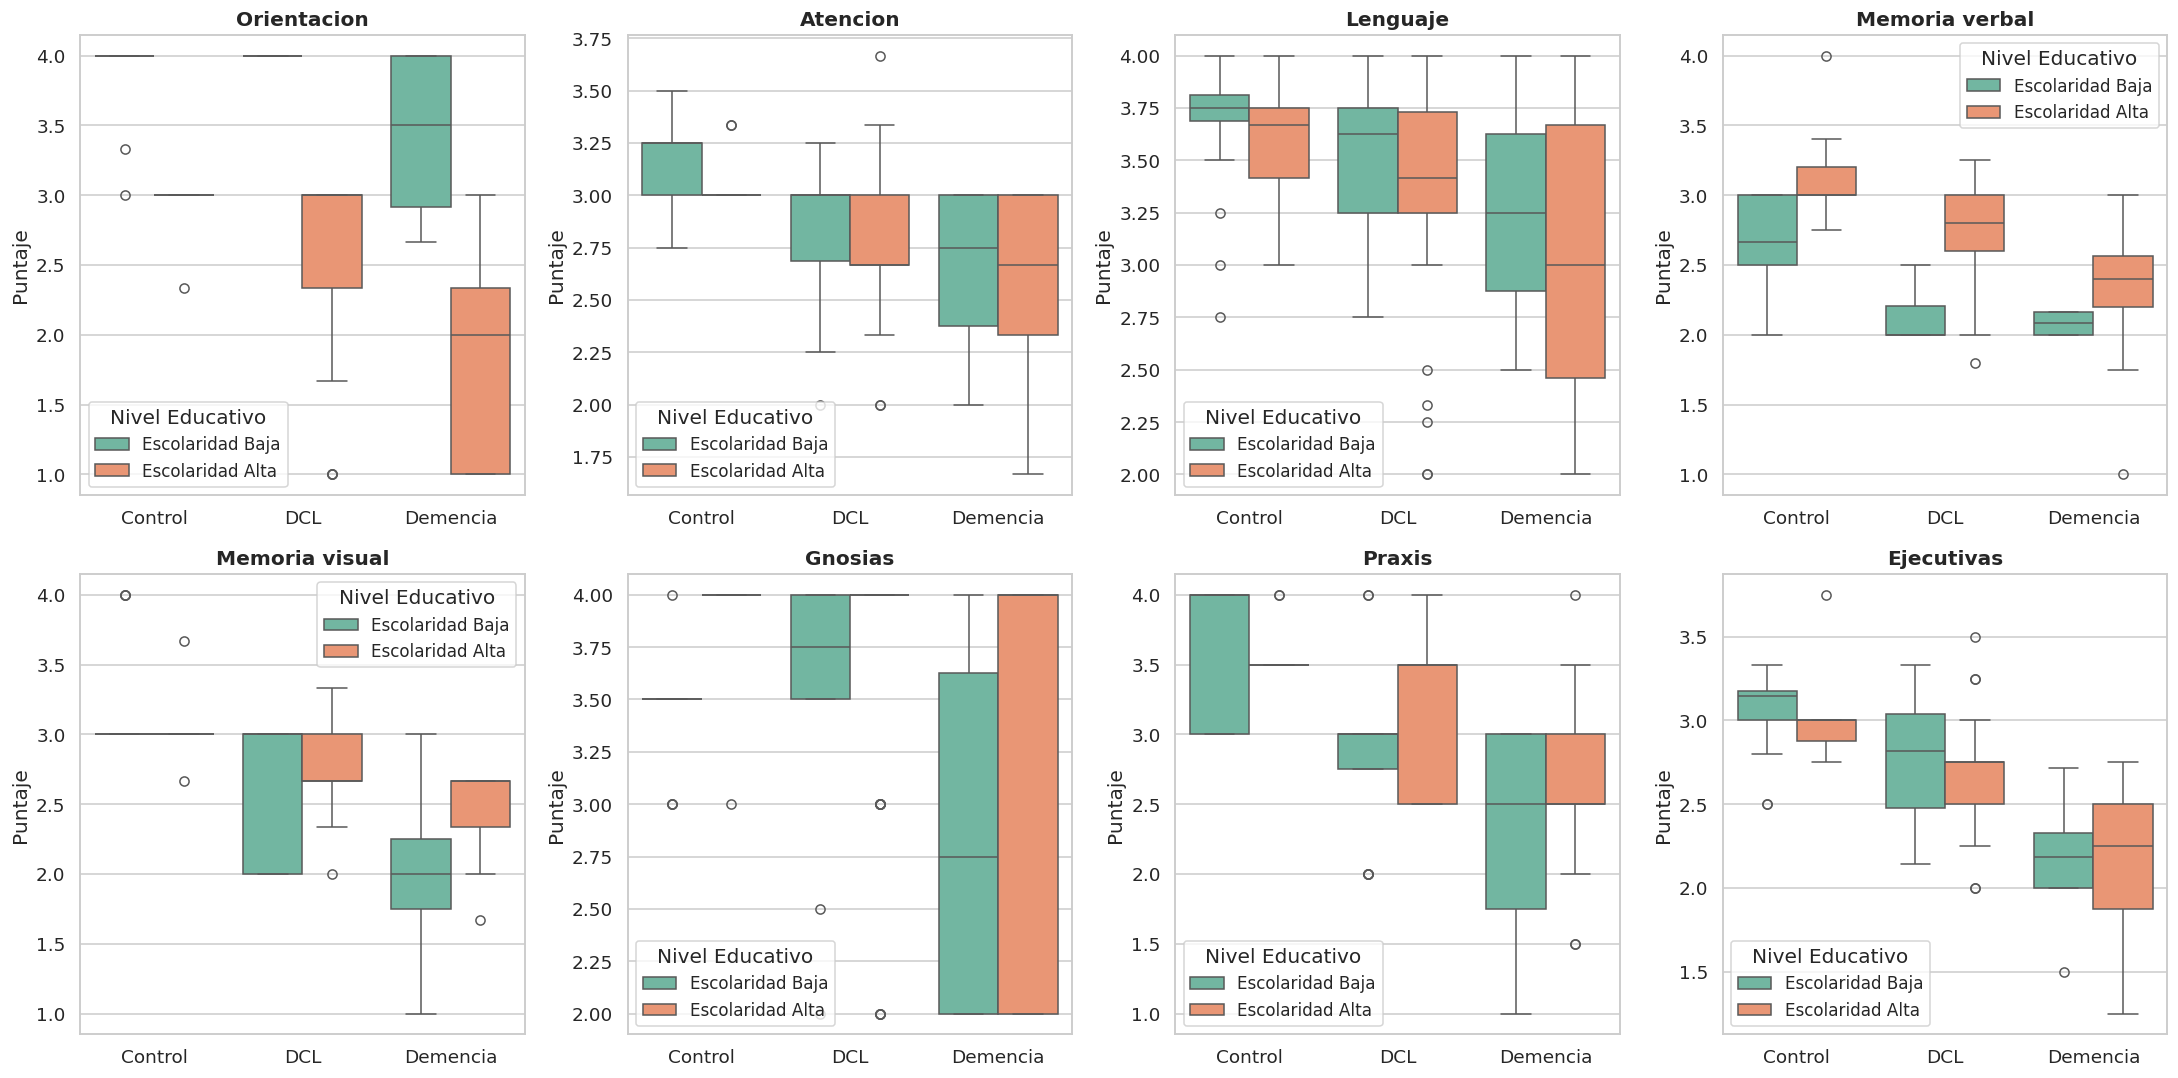

In [57]:
# Mapeamos ambas columnas (educación y grupo clínico) para la gráfica
df_mapped = df_complete.assign(
    nivel_estudio_texto = df_complete["nivel_estudio"].map(EDUCATION_LEVEL),
    # Nos aseguramos de mapear la columna dc a sus textos ("Control", "DCL", "Demencia")
    dc_texto = pd.to_numeric(df_complete["dc"], errors='coerce').map(DC_LABELS) 
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Iteramos sobre tus dominios cognitivos
for ax, dominio in zip(axes, DOMINIOS):
    # Boxplot agrupado por DC y coloreado por Nivel de Estudio
    sns.boxplot(
        data=df_mapped, 
        x="dc_texto", 
        y=dominio, 
        hue="nivel_estudio_texto", 
        order=[DC_LABELS[0], DC_LABELS[1], DC_LABELS[2]], # Mantiene el orden lógico
        ax=ax, 
        palette="Set2"
    )
    ax.set_title(dominio.capitalize().replace("_", " "), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Puntaje")
    ax.legend(title="Nivel Educativo", fontsize='small')

plt.tight_layout()
plt.show()


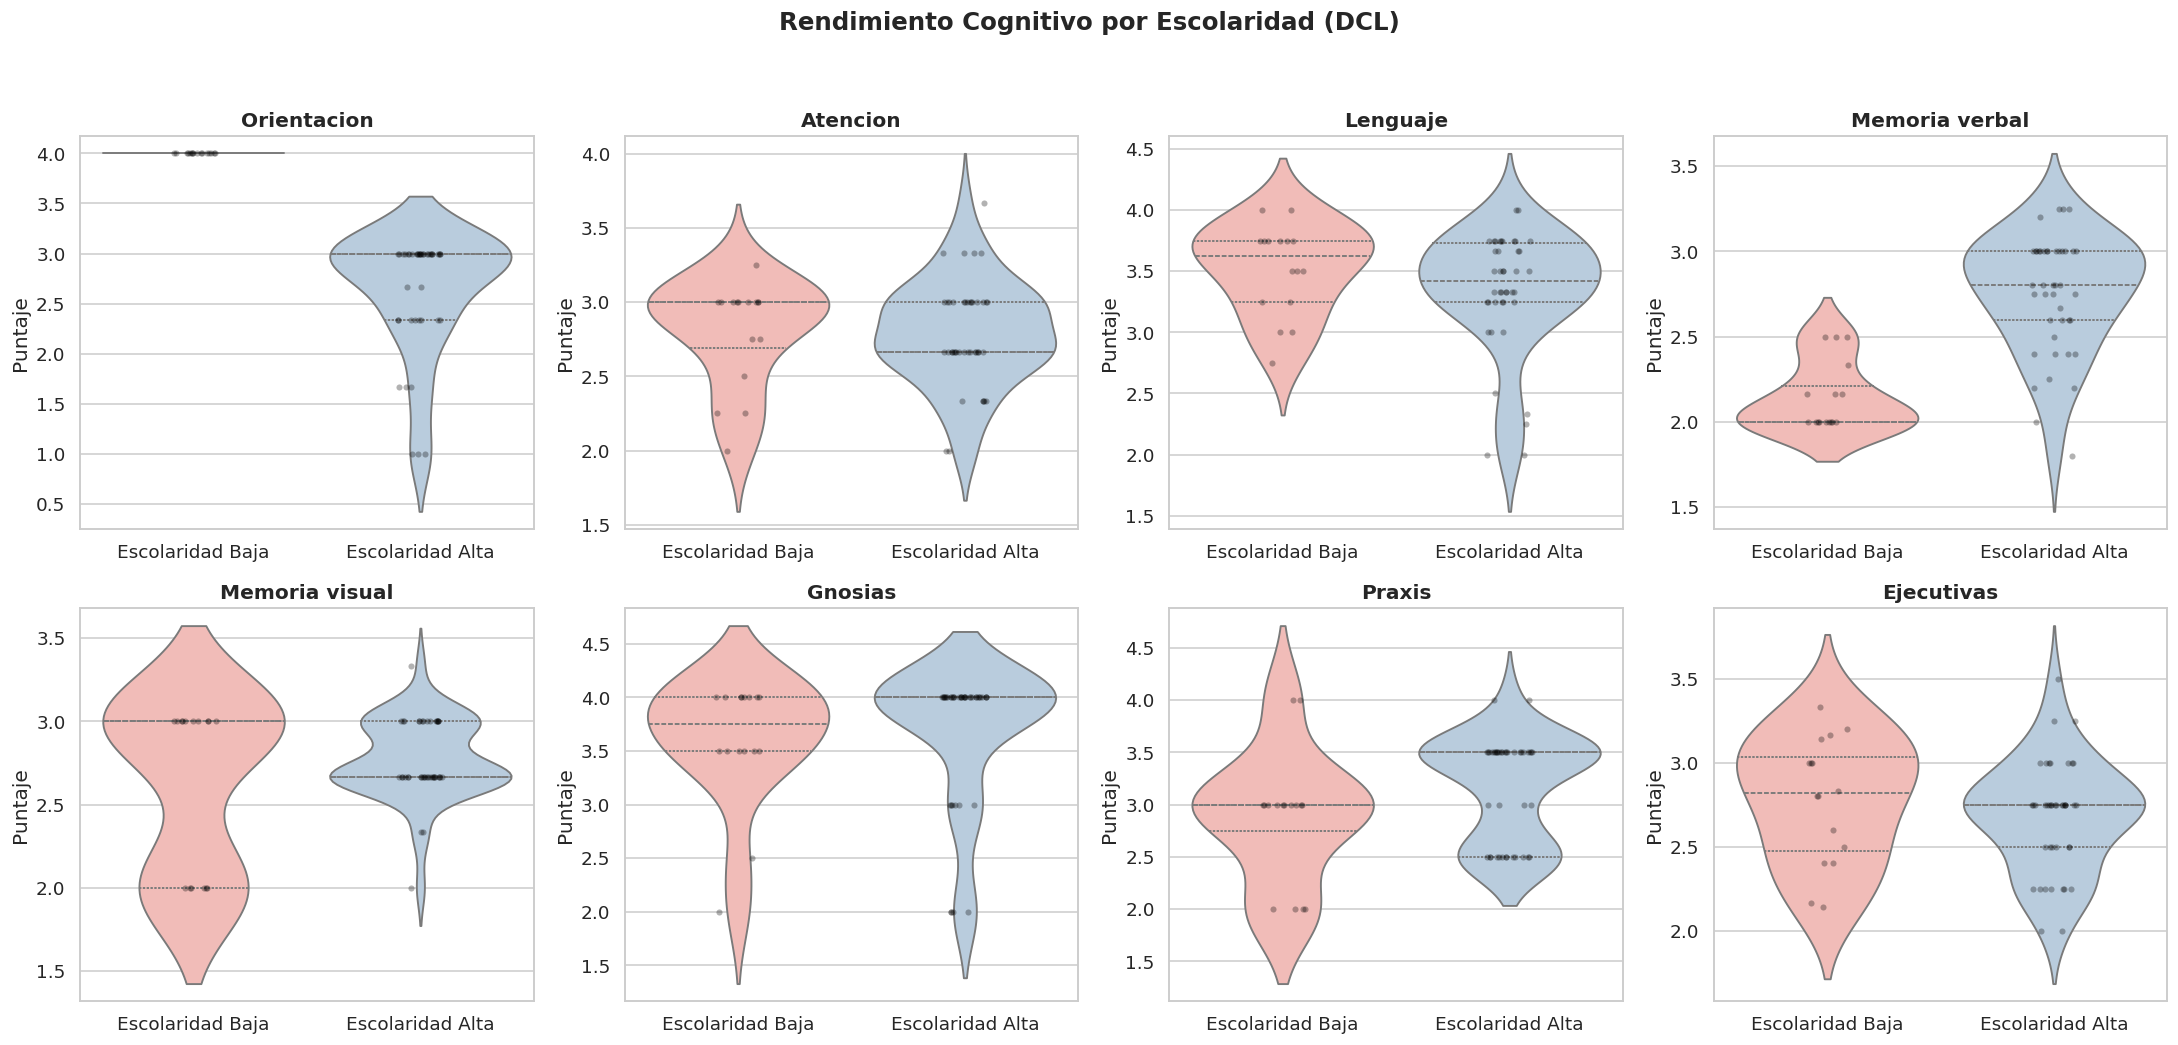

In [58]:
# Filtramos solo a los pacientes del grupo deterioro leve
df_leve = df_complete[df_complete["dc"] == '1'].copy()
df_leve = df_leve.assign(nivel_estudio_texto=df_leve["nivel_estudio"].map(EDUCATION_LEVEL))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, dominio in zip(axes, DOMINIOS):
    sns.violinplot(
        data=df_leve, 
        x="nivel_estudio_texto", 
        y=dominio, 
        ax=ax, 
        palette="Pastel1",
        inner="quartile" # Muestra las líneas de los cuartiles por dentro
    )
    
    # Un "stripplot" superpuesto dibuja cada paciente como un puntito
    sns.stripplot(
        data=df_leve, 
        x="nivel_estudio_texto", 
        y=dominio, 
        color="black", 
        alpha=0.3, 
        size=4,
        ax=ax
    )
    
    ax.set_title(dominio.capitalize().replace("_", " "), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Puntaje")

fig.suptitle("Rendimiento Cognitivo por Escolaridad (DCL)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Deja espacio para el título principal
plt.show()


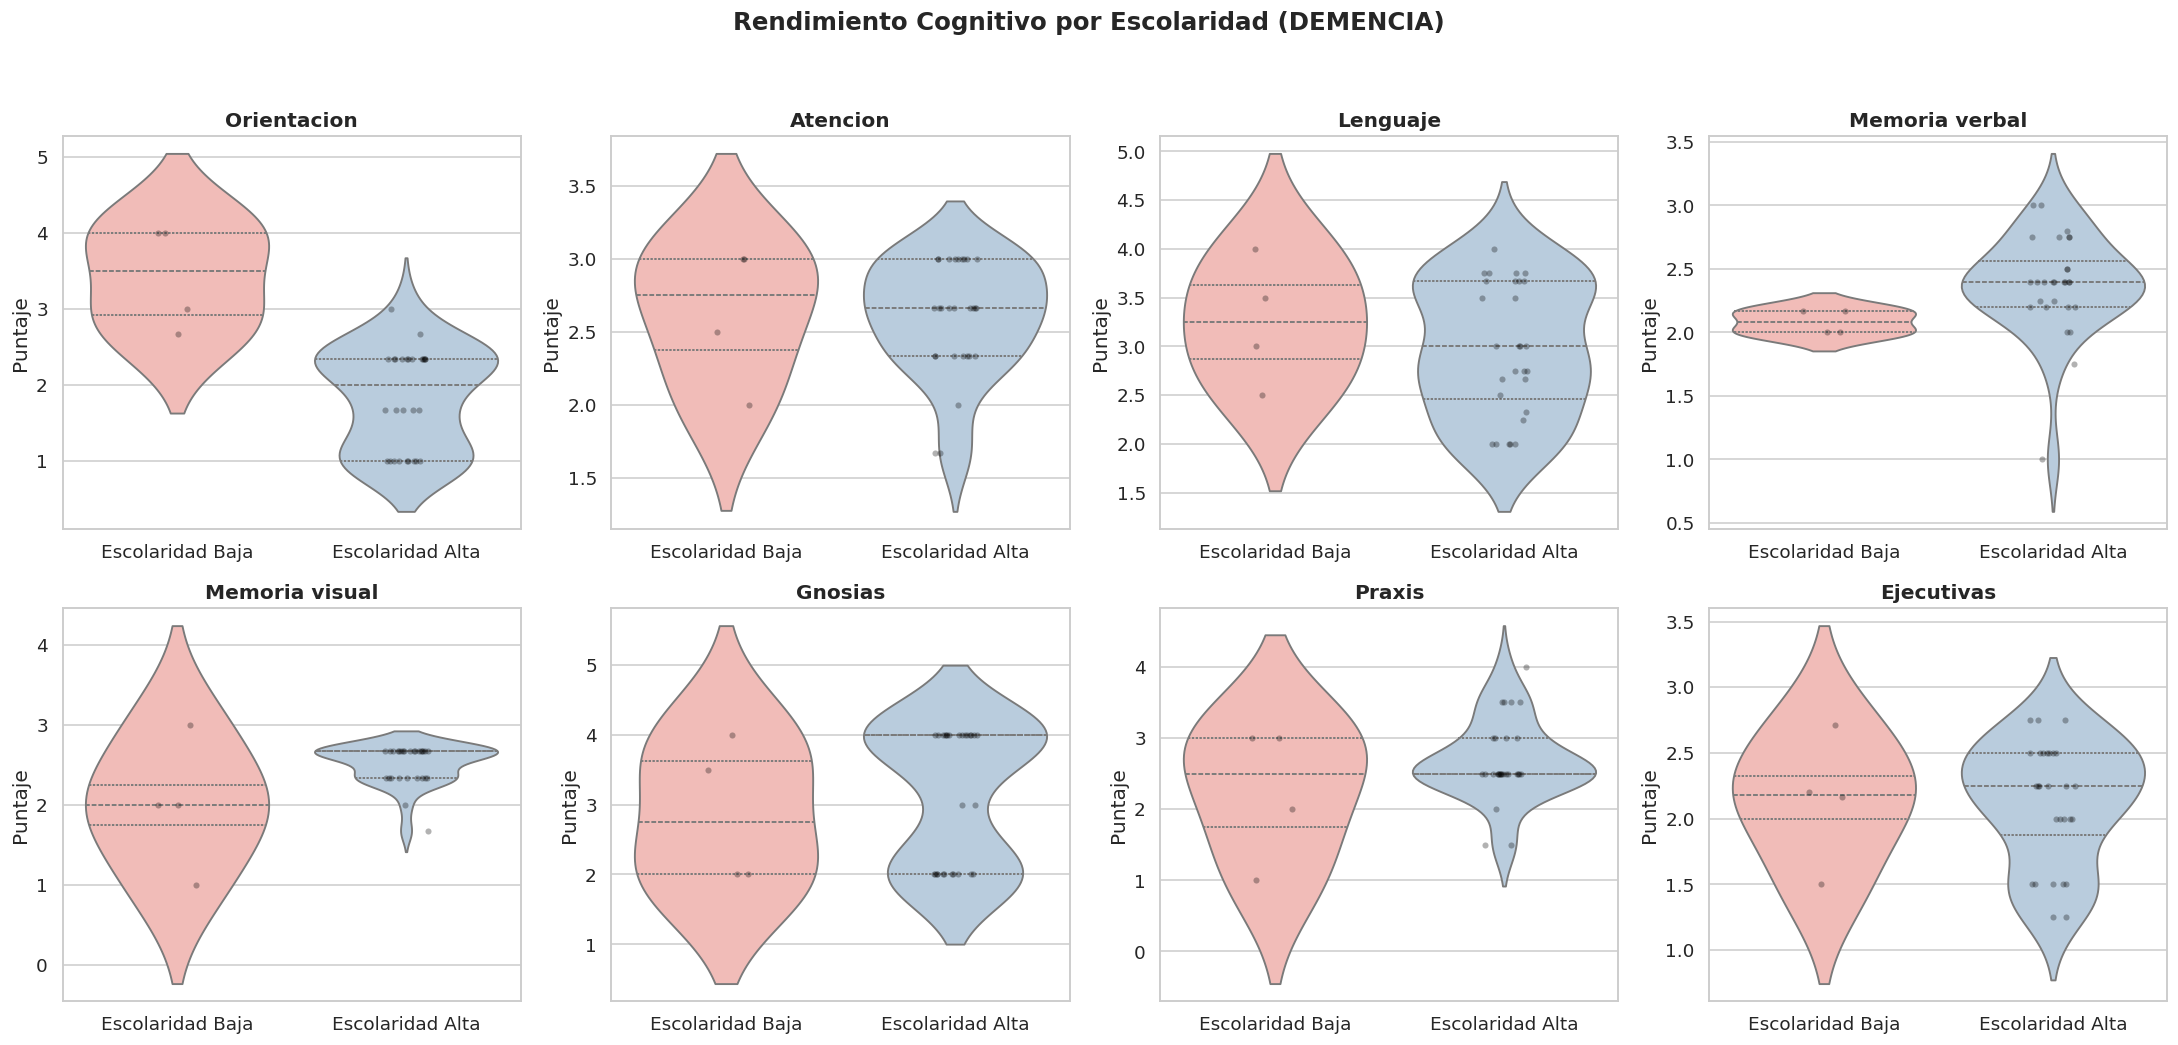

In [59]:
# Filtramos solo a los pacientes del grupo con demencia
df_demencia = df_complete[df_complete["dc"] == '2'].copy() 
df_demencia = df_demencia.assign(nivel_estudio_texto=df_demencia["nivel_estudio"].map(EDUCATION_LEVEL))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, dominio in zip(axes, DOMINIOS):
    sns.violinplot(
        data=df_demencia, 
        x="nivel_estudio_texto", 
        y=dominio, 
        ax=ax, 
        palette="Pastel1",
        inner="quartile" # Muestra las líneas de los cuartiles por dentro
    )
    
    # Un "stripplot" superpuesto dibuja cada paciente como un puntito
    sns.stripplot(
        data=df_demencia, 
        x="nivel_estudio_texto", 
        y=dominio, 
        color="black", 
        alpha=0.3, 
        size=4,
        ax=ax
    )
    
    ax.set_title(dominio.capitalize().replace("_", " "), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Puntaje")

fig.suptitle("Rendimiento Cognitivo por Escolaridad (DEMENCIA)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Deja espacio para el título principal
plt.show()


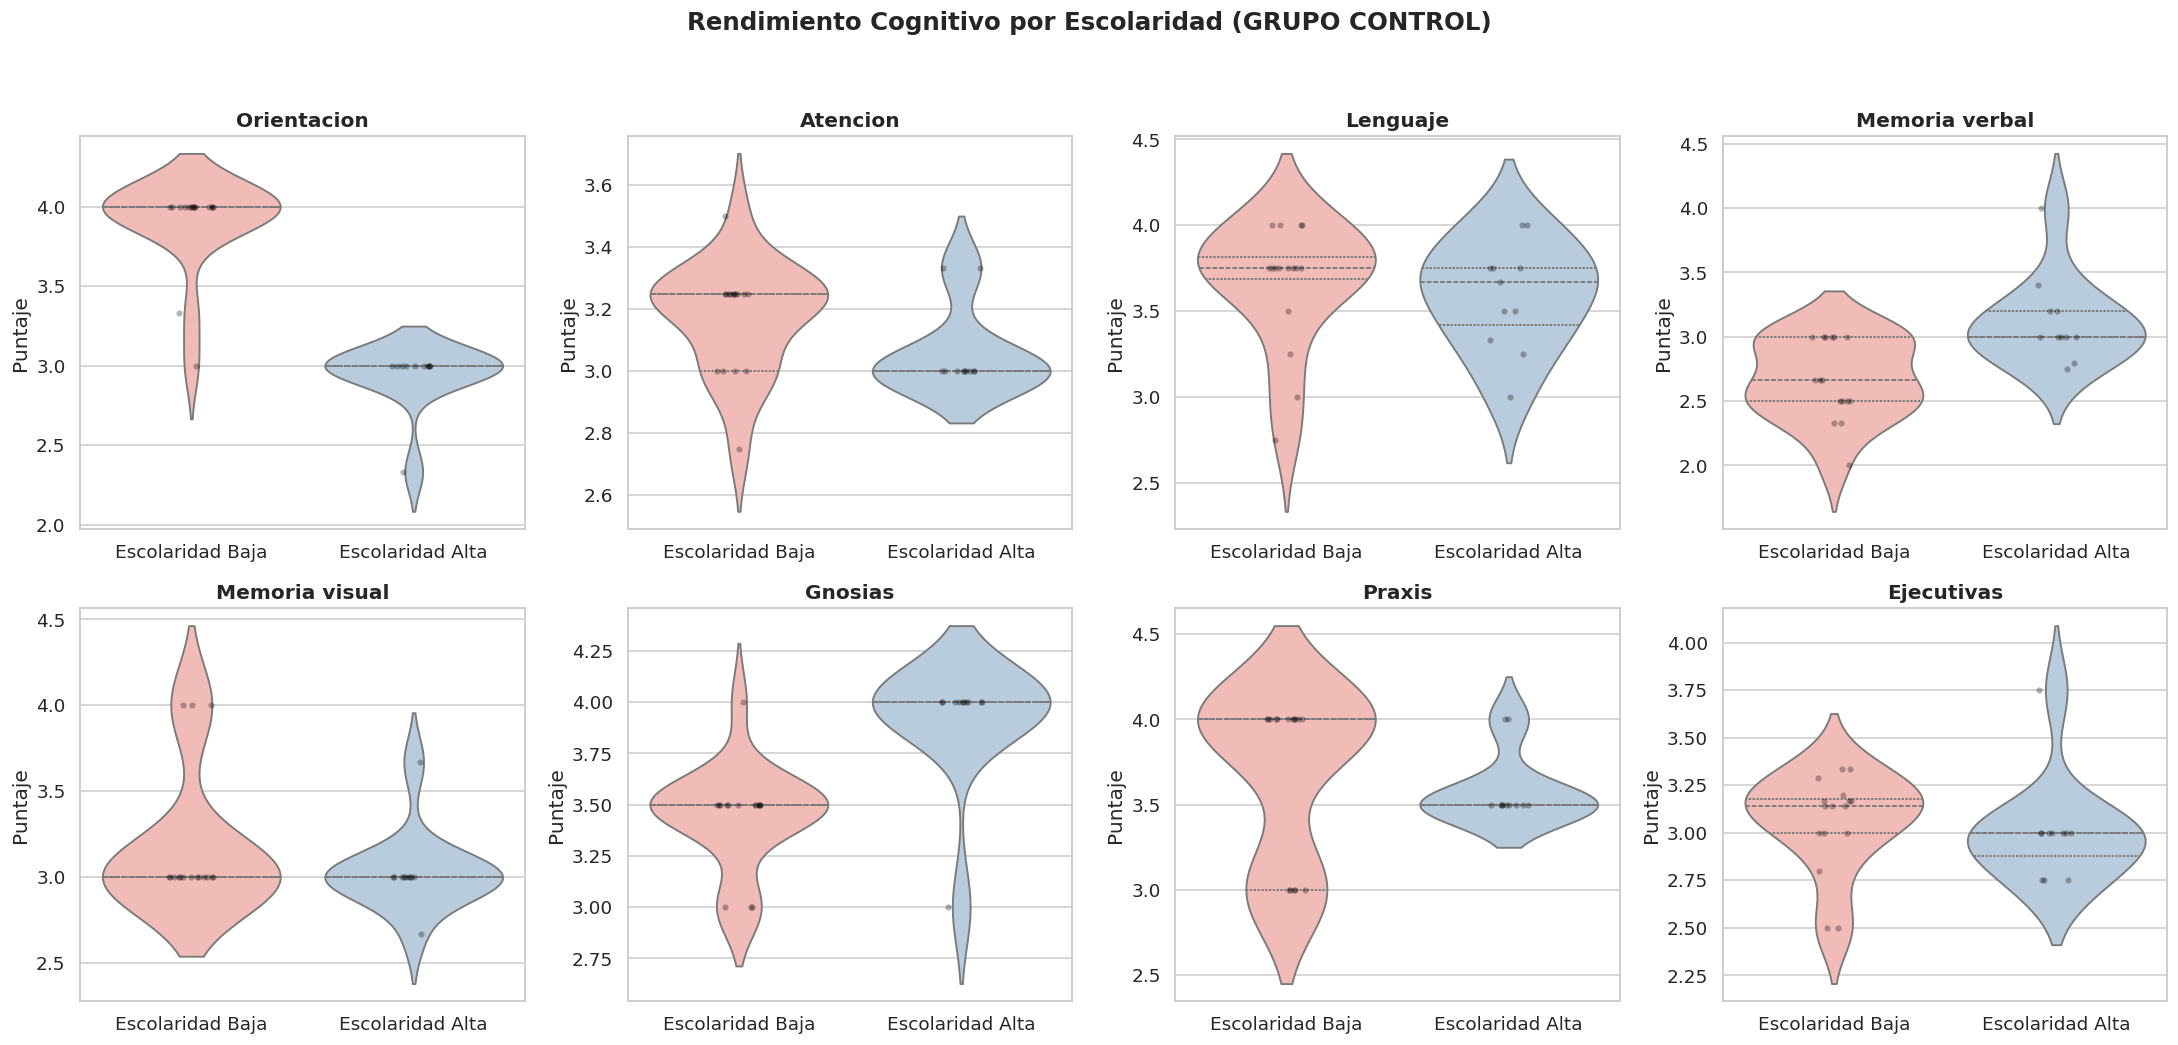

In [60]:
# Filtramos solo a los pacientes del grupo control
df_control = df_complete[df_complete["dc"] == '0'].copy() # Asumiendo que 0 es Control
df_control = df_control.assign(nivel_estudio_texto=df_control["nivel_estudio"].map(EDUCATION_LEVEL))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, dominio in zip(axes, DOMINIOS):
    sns.violinplot(
        data=df_control, 
        x="nivel_estudio_texto", 
        y=dominio, 
        ax=ax, 
        palette="Pastel1",
        inner="quartile" # Muestra las líneas de los cuartiles por dentro
    )
    
    # Un "stripplot" superpuesto dibuja cada paciente como un puntito
    sns.stripplot(
        data=df_control, 
        x="nivel_estudio_texto", 
        y=dominio, 
        color="black", 
        alpha=0.3, 
        size=4,
        ax=ax
    )
    
    ax.set_title(dominio.capitalize().replace("_", " "), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Puntaje")

fig.suptitle("Rendimiento Cognitivo por Escolaridad (GRUPO CONTROL)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Deja espacio para el título principal
plt.show()


Con 125 pacientes (n = 125), estás trabajando con un dataset clasificado como "pequeño" en el mundo del Machine Learning. Además, al tratarse de un problema médico/clínico, la interpretabilidad de las predicciones es casi tan importante como su precisión (los médicos necesitan saber por qué el modelo clasifica a alguien con Demencia).

Tu problema es de Clasificación Multiclase (Control = 0, DCL = 1, Demencia = 2). Además, tus clases tienen un orden lógico (sano -> leve -> severo).

Aquí tienes los modelos que te recomiendo, ordenados de más simples a más complejos:

1. Modelos "Caja Blanca" (Alta interpretabilidad)
Estos son los modelos favoritos en entornos clínicos porque te permiten explicar fácilmente la decisión.

Regresión Logística Multinomial o Regresión Ordinal:
Por qué: Es el estándar de oro en bioestadística. Te dará "Odds Ratios", es decir, te permitirá decir: "Por cada punto que baja la memoria visual, el riesgo de demencia aumenta un X%". Dado que tus clases tienen un orden (Control -> DCL -> Demencia), una Regresión Logística Ordinal sería matemáticamente perfecta.
Árboles de Decisión (Decision Trees):
Por qué: Puedes imprimir el árbol y mostrárselo a un psicólogo o médico como un diagrama de flujo (Ej: Si Edad > 65 y Memoria Verbal < 2.5 ➡️ Demencia).
Ojo: Tienden a sobreajustar (overfitting), así que debes limitar su profundidad máxima (max_depth = 3 o 4).
2. Modelos de Ensamble (Mejor precisión)
Suelen ser los ganadores en este tipo de datos tabulares, aunque pierdes un poco de interpretabilidad.

Random Forest (Bosques Aleatorios):
Por qué: Maneja muy bien el ruido, no requiere escalar los datos, e identifica qué variables son más importantes (feature_importances_). Dado tu n=125, debes usar pocos árboles (n_estimators=100) y poca profundidad.
XGBoost o LightGBM:
Por qué: Son los reyes actuales de los datos tabulares. Probablemente te den la mejor métrica final.
Ojo: Con 125 filas, un XGBoost puede memorizar los datos muy rápido. Tendrás que usar una tasa de aprendizaje muy baja (learning_rate=0.01), poca profundidad (max_depth=2 o 3) y fuerte regularización.
3. Modelos Geométricos
Support Vector Machines (SVM) (Kernel Lineal o RBF):
Por qué: SVM fue diseñado originalmente para destacar en datasets pequeños (n < 1000). Funciona construyendo "fronteras" entre los pacientes en un espacio multidimensional. Requiere que escales tus datos previamente (MinMaxScaler o StandardScaler).
K-Nearest Neighbors (KNN):
Por qué: Tiene mucha lógica clínica. Básicamente clasifica a un paciente nuevo mirando cómo están los 5 pacientes históricamente más parecidos a él.
⚠️ Recomendaciones críticas para tu entrenamiento:
Dado que tienes muy pocos datos (n=125), no uses un simple train_test_split. Si dejas un 20% para pruebas, estarás evaluando tu modelo con solo 25 pacientes. La suerte al elegir esos 25 afectará drásticamente tu métrica.

Usa Validación Cruzada Estratificada (Stratified K-Fold CV): Te recomiendo usar KFold=5. Así entrenas y validas con todos tus datos en 5 iteraciones, manteniendo la proporción de Control/DCL/Demencia.
Manejo de Desbalance: Tienes 58 DCL, 32 Demencia y 27 Controles. Cuando entrenes, asegúrate de pasar el parámetro class_weight='balanced' en tus modelos (Logistic Regression, Random Forest) para que el modelo no se vuelva sesgado a predecir siempre "DCL".
Métricas: No uses el "Accuracy" (Precisión global). Usa el F1-Score Macro y Matriz de Confusión, ya que te interesa saber específicamente cuántos pacientes de Demencia los catalogó por error como Controles (lo cual sería un error médico grave).
¿Por dónde empezar? Te recomiendo armar un Pipeline simple en scikit-learn que pruebe Regresión Logística, Random Forest y SVM usando validación cruzada. El que te dé mejor F1-score y tenga mayor sentido clínico debería ser tu modelo elegido.

¿Qué debes observar al ejecutar esto?
F1-Score Macro: El mejor modelo debería estar idealmente por encima de 0.70 - 0.75.
Desviación Estándar (Std): Si un modelo tiene un F1-Score muy alto pero un Std muy grande (ej. 0.20), significa que fue muy inestable durante la validación cruzada y sus resultados son producto de la suerte en cómo se dividieron los datos. Un modelo con un F1 ligeramente menor pero con un Std pequeño (ej. 0.05) es mucho más confiable.

Lo más importante: Cambia la forma en la que mides el éxito
Con datos desbalanceados, si un modelo predice "DCL" para todos, obtendrá un casi 50% de Accuracy sin haber aprendido nada. Por lo tanto, no mires el Accuracy.

En tu código, evalúa tus modelos usando:

Macro F1-Score: Calcula el F1-Score (balance entre precisión y exhaustividad) para cada una de las 3 clases y saca un promedio igualitario. Un modelo no puede sacar buen Macro F1 si ignora a los Controles.
Balanced Accuracy: Es el promedio del "Recall" (sensibilidad) obtenido en cada clase por separado.
Matriz de Confusión: Es tu mejor amiga. Visualízala siempre. Te permitirá ver exactamente si tu modelo está confundiendo a los Controles con DCL, o si se está perdiendo pacientes con Demencia severa.

¡Excelente decisión! Vamos a construir un pipeline limpio, robusto y profesional usando scikit-learn.

Este código lo puedes copiar y pegar en una nueva celda al final de tu notebook. El código hace exactamente lo siguiente:

Define tus variables predictoras (X) y tu variable objetivo (y).
Crea un Pipeline que automáticamente imputa valores faltantes (si los hay) y escala los datos (paso obligatorio para que funcionen bien SVM y la Regresión Logística).
Configura Stratified 5-Fold Cross Validation para asegurar que el entrenamiento sea justo y evaluar todos los datos.
Evalúa los modelos Regresión Logística, Random Forest y SVM (Lineal y RBF) usando las métricas correctas (F1-Score Macro y Balanced Accuracy). Todos los modelos están configurados con class_weight="balanced".

In [61]:
# Importamos las librerías necesarias de scikit-learn
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold


# 1. Definir características (X) y objetivo (y)
# Suponiendo que tus características predictoras son los dominios más edad y nivel de estudio
# (Asegúrate de que 'age_num' sea el nombre correcto en tu dataframe)
features = DOMINIOS + ["age", "nivel_estudio"]
X = df_complete[features]

# Asegurar que el target sea un valor entero válido
y = pd.to_numeric(df_complete["dc"], errors='coerce').fillna(-1).astype(int)

# Filtramos filas que tengan un target inválido (como 'No determinada' que se volvió -1)
mask = y != -1
X = X[mask]
y = y[mask]


# 2. Definir el diccionario de modelos con balanceo de clases algorítmico
models = {
    "Regresión Logística": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    # Limitamos la profundidad del Random Forest a 3 para evitar overfitting en el dataset pequeño
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=200, min_samples_leaf=5,min_samples_split=10,max_features="sqrt",  max_depth=3, random_state=42),
    "SVM (Lineal)": SVC(kernel="linear", class_weight="balanced", random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", random_state=42)
}

# Hacemos 5-Folds, pero repetimos el sorteo y el proceso entero 10 veces
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

# Métricas recomendadas para datos desbalanceados
scoring = ['f1_macro', 'balanced_accuracy']

# Lista para guardar los resultados
results = []

# 4. Bucle principal de evaluación
print("Iniciando entrenamiento y validación cruzada...")
for name, model in models.items():
    
    # Creamos un Pipeline de 3 pasos:
    # Paso 1: Rellenar NaNs con la mediana (SimpleImputer)
    # Paso 2: Escalar los datos a Media=0, Std=1 (StandardScaler)
    # Paso 3: Entrenar el clasificador
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Ejecutar la validación cruzada
    cv_scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": name,
        "F1-Score Macro": cv_scores['test_f1_macro'].mean(),
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std()
    })

# 5. Convertir resultados a DataFrame, ordenar de mejor a peor, y mostrar
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("-" * 70)
print("🏆 RESULTADOS DE LOS MODELOS (ORDENADOS POR F1-SCORE MACRO)")
print("-" * 70)
display(df_results.round(4))


Iniciando entrenamiento y validación cruzada...
----------------------------------------------------------------------
🏆 RESULTADOS DE LOS MODELOS (ORDENADOS POR F1-SCORE MACRO)
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std)
3,SVM (RBF),0.7815,0.0687,0.7927,0.0721
1,Random Forest,0.7622,0.0961,0.7812,0.1038
2,SVM (Lineal),0.7609,0.0791,0.7816,0.0771
0,Regresión Logística,0.7597,0.0819,0.7725,0.0867


Para saber si un modelo se sobreentrenó (overfitting), la regla de oro es comparar qué tan bien le fue en el "examen de práctica" (datos de entrenamiento) contra qué tan bien le fue en el "examen real" (datos de validación).

Si el F1-Score de entrenamiento es 0.95 pero el de validación es 0.60 ➡️ ¡Se sobreentrenó! (Memorizó los datos pero no sabe generalizar).
Si el F1-Score de entrenamiento es 0.75 y el de validación es 0.71 ➡️ Está generalizando bien (No hay sobreentrenamiento grave).
Si ambos son bajos (ej. 0.50 y 0.48) ➡️ Underfitting (El modelo es demasiado simple y no aprendió nada).
En el código que te pasé antes, le pedimos a scikit-learn que solo nos devolviera la nota del examen real (return_train_score=False). Para ver si hay sobreentrenamiento, solo necesitas cambiar esa línea a True y capturar el resultado de entrenamiento.

Aquí tienes el fragmento de código actualizado (solo el bloque del bucle):
Reemplaza tu bucle for actual con este. Añadí la métrica de entrenamiento y una columna "Brecha (Gap)" que te dirá inmediatamente cuánto está cayendo el rendimiento:

In [62]:
# Lista para guardar los nuevos resultados
results_overfitting = []

for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # ¡CAMBIO CLAVE AQUÍ! return_train_score=True
    cv_scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=True)
    
    # Extraemos medias
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    
    results_overfitting.append({
        "Modelo": name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })

# Mostrar resultados
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("-" * 85)
print("🔍 ANÁLISIS DE SOBREENTRENAMIENTO (OVERFITTING)")
print("-" * 85)
display(df_overfit.round(4))


-------------------------------------------------------------------------------------
🔍 ANÁLISIS DE SOBREENTRENAMIENTO (OVERFITTING)
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
3,SVM (RBF),0.9137,0.7815,0.1322,0.0687
1,Random Forest,0.8703,0.7622,0.1081,0.0961
2,SVM (Lineal),0.8724,0.7609,0.1115,0.0791
0,Regresión Logística,0.8680,0.7597,0.1083,0.0819


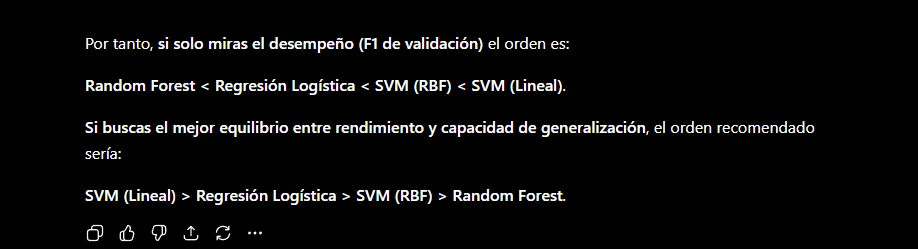

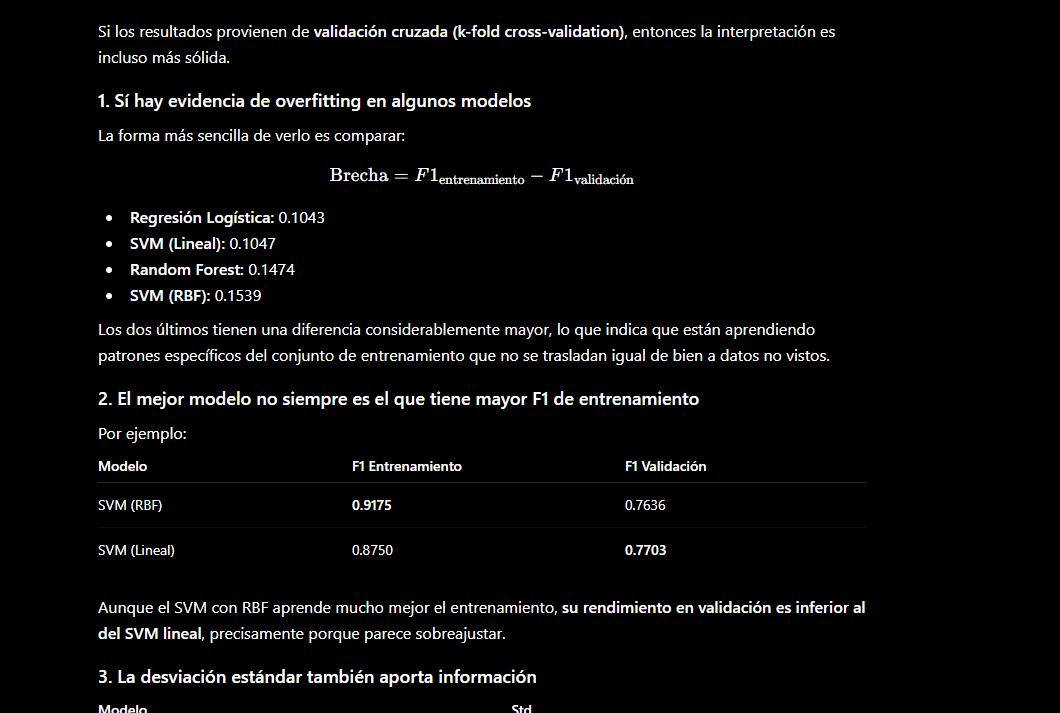

Diagonal principal (Azul oscuro): Son los pacientes que el modelo diagnosticó correctamente.
Fuera de la diagonal: Son los errores. Presta atención a la esquina superior derecha (Controles sanos que el modelo diagnosticó con Demencia) y la esquina inferior izquierda (Pacientes con Demencia que el modelo dijo que estaban sanos). El mejor modelo será el que tenga menos errores en esas dos esquinas críticas.

ValueError: cross_val_predict only works for partitions

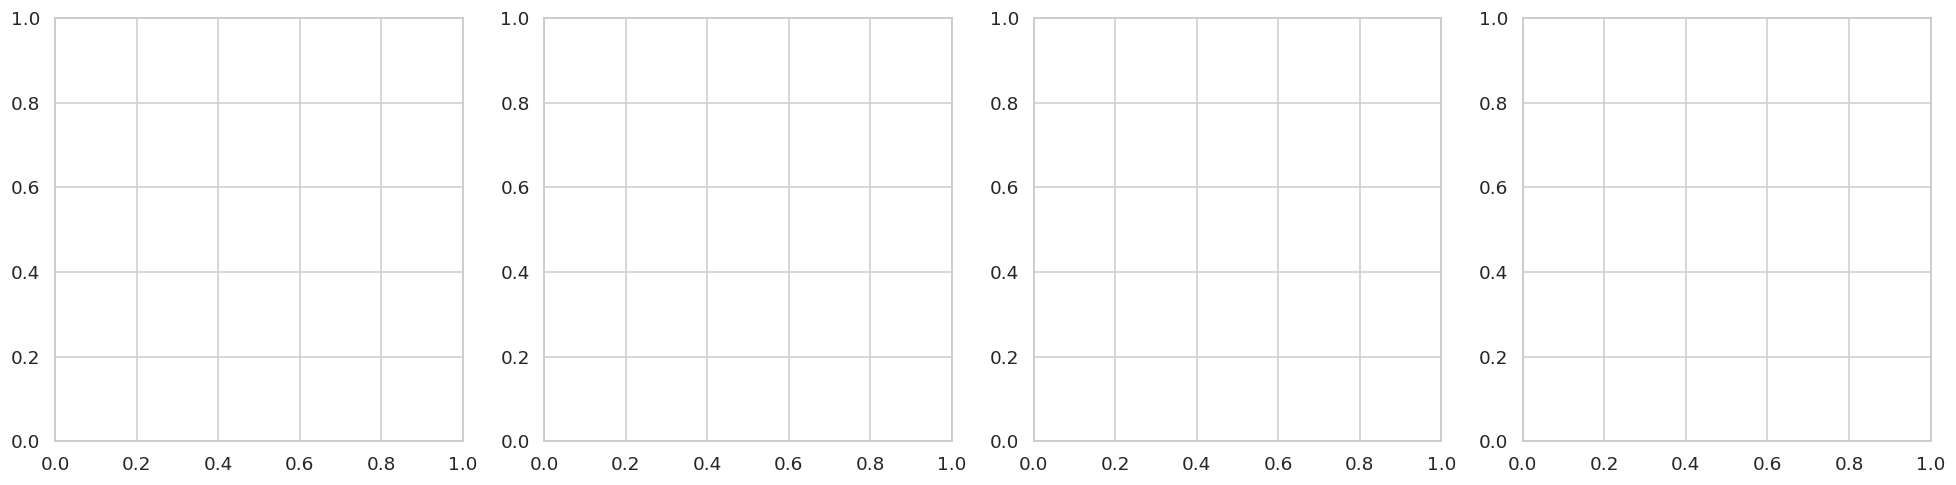

In [63]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Creamos una figura ancha para poner las matrices una al lado de la otra
fig, axes = plt.subplots(1, len(models), figsize=(22, 5))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),                 
        ('classifier', model)
    ])
    
    # Genera predicciones para todo el dataset, pero cada paciente es 
    # evaluado solo cuando su fold fue el "fold de prueba" (sin trampa).
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    
    # Calcula y grafica la matriz
    cm = confusion_matrix(y, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Control", "DCL", "Demencia"])
    
    # Personalización visual
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"{name}", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicción del Modelo", fontsize=11)
    ax.set_ylabel("Diagnóstico Clínico Real", fontsize=11)

plt.tight_layout()
plt.show()


🧐 Cómo interpretar esto: El modelo repartirá un 100% de importancia entre todas las variables. Si, por ejemplo, "Orientacion" y "Funciones Ejecutivas" suman el 50% de la importancia, significa que la mitad del diagnóstico médico (según el algoritmo) recae únicamente en los resultados de esas dos pruebas. Te sorprenderá ver dónde queda posicionada la "Edad" frente al "Nivel de estudio".

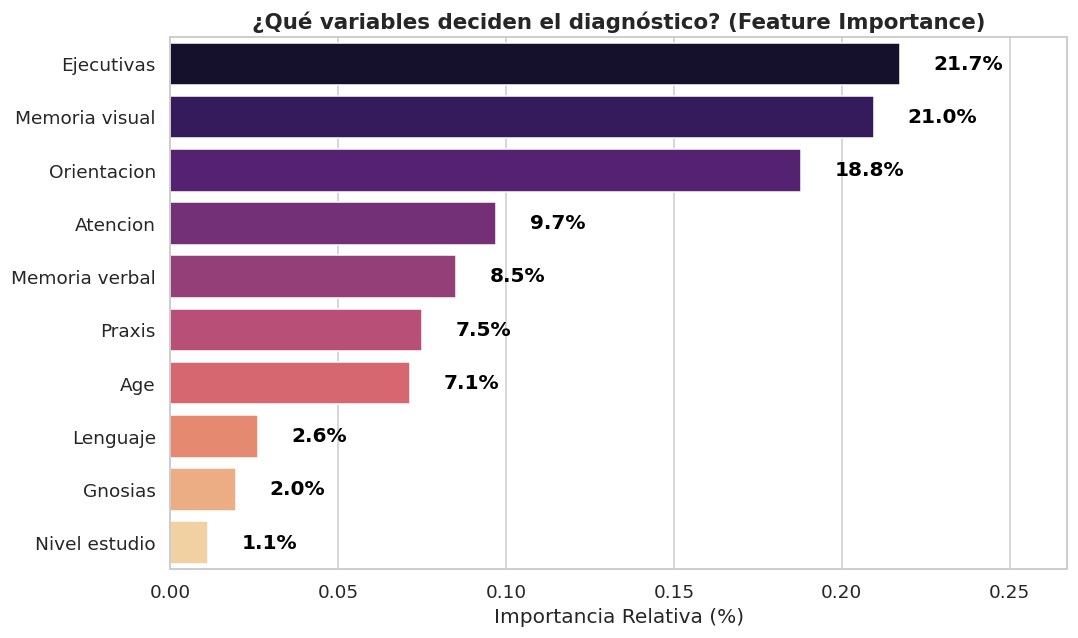

In [ ]:
import seaborn as sns

# Para ver la importancia global, entrenamos el Random Forest con TODOS los datos
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    # Nota: No necesitamos scaler para Random Forest
    ('classifier', RandomForestClassifier(class_weight="balanced", n_estimators=100, max_depth=3, random_state=42))
])

rf_pipeline.fit(X, y)

# Extraemos la importancia de cada variable
importancias = rf_pipeline.named_steps['classifier'].feature_importances_

# Creamos un dataframe ordenado
df_imp = pd.DataFrame({
    'Variable': X.columns.str.capitalize().str.replace("_", " "),
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficamos
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_imp, x='Importancia', y='Variable', palette="magma", ax=ax)

ax.set_title("¿Qué variables deciden el diagnóstico? (Feature Importance)", fontweight="bold", fontsize=14)
ax.set_xlabel("Importancia Relativa (%)")
ax.set_ylabel("")

# Añadir el porcentaje en texto al lado de cada barra
for i, v in enumerate(df_imp['Importancia']):
    ax.text(v + 0.01, i + 0.1, f"{v*100:.1f}%", color='black', fontweight='bold')

plt.xlim(0, max(importancias) + 0.05) # Ajustar el margen derecho
plt.tight_layout()
plt.show()


In [ ]:
# Tomemos al paciente en la fila 5 de tu dataset de ejemplo
paciente_ejemplo = X.iloc[[5]]

# Usamos predict_proba en lugar de predict
probabilidades = rf_pipeline.predict_proba(paciente_ejemplo)[0]

print("REPORTE CLÍNICO DEL ALGORITMO:")
print(f"Probabilidad de ser Control Sano : {probabilidades[0]*100:.1f}%")
print(f"Probabilidad de tener DCL        : {probabilidades[1]*100:.1f}%")
print(f"Probabilidad de tener Demencia   : {probabilidades[2]*100:.1f}%")


REPORTE CLÍNICO DEL ALGORITMO:
Probabilidad de ser Control Sano : 7.7%
Probabilidad de tener DCL        : 74.7%
Probabilidad de tener Demencia   : 17.6%


2. Valores SHAP (Radiografía del Razonamiento del Modelo)
Esta es la técnica definitiva. SHAP te permite imprimir un gráfico para un solo paciente en específico que le dice al médico: "Este paciente tiene DCL porque su Memoria Verbal le restó 15 puntos a su salud, pero su edad temprana le sumó 5".

Un detalle para tu gráfico:
Una vez que corras esto, verás el Beeswarm Plot.

El color (rojo o azul) representa el valor original del paciente (rojo = valor alto en esa prueba/edad, azul = valor bajo).
El eje horizontal (SHAP value) representa hacia dónde empujó ese valor al diagnóstico. Si está a la derecha del 0, empujó la probabilidad a favor de diagnosticar Demencia. Si está a la izquierda, redujo la probabilidad.

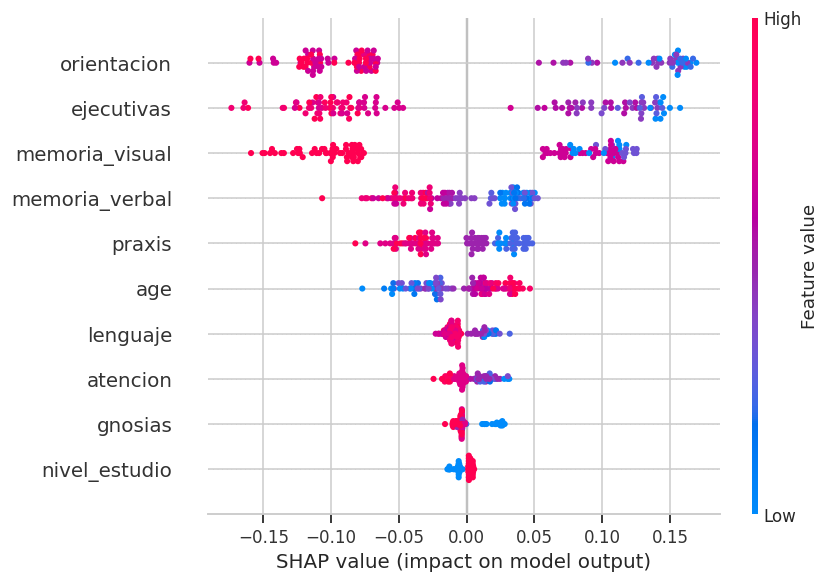

In [ ]:
import shap

# Inicializamos Javascript
shap.initjs()

# Extraemos el Random Forest ya entrenado y los datos limpios
rf_model = rf_pipeline.named_steps['classifier']
imputer = rf_pipeline.named_steps['imputer']
X_limpio = imputer.transform(X)

# Creamos el analizador SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_limpio)

# --- SOLUCIÓN AL ERROR DE DIMENSIONES ---
# Verificamos cómo estructuró SHAP los datos (Lista vs Matriz 3D)
if isinstance(shap_values, list):
    # Versiones antiguas: Es una lista. El índice 2 corresponde a la clase 'Demencia'
    shap_demencia = shap_values[2]
else:
    # Versiones nuevas: Es un cubo 3D [pacientes, variables, clases]
    # Cortamos el cubo para extraer solo la rebanada de la clase 2 ('Demencia')
    shap_demencia = shap_values[:, :, 2]

# Ahora sí graficamos garantizando que las dimensiones son exactas
shap.summary_plot(shap_demencia, X_limpio, feature_names=X.columns, title="Impacto de Variables para diagnosticar Demencia")


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. BÚSQUEDA PARA SVM LINEAL
print("🔍 Afinando Support Vector Machine (Lineal)...")
pipeline_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('classifier', SVC(kernel='linear', class_weight='balanced', random_state=42))
])

# Parámetro 'C': C bajos = modelo más simple/general. C altos = modelo muy complejo/ajustado
parametros_svm = {
    'classifier__C': [0.01, 0.1, 1, 10, 50] 
}

grid_svm = GridSearchCV(pipeline_svm, parametros_svm, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_svm.fit(X, y)
print(f"Mejor 'C' para SVM: {grid_svm.best_params_}")
print(f"F1-Score Máximo: {grid_svm.best_score_:.4f}\n")


# 2. BÚSQUEDA PARA RANDOM FOREST
print("🔍 Afinando Random Forest...")
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),                
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# max_depth: Profundidad. n_estimators: Cantidad de árboles.
parametros_rf = {
    'classifier__max_depth': [2, 3, 4, 5], 
    'classifier__n_estimators': [50, 100, 200],
    'classifier__min_samples_leaf': [1, 2, 5] # Obliga a detenerse si no quedan bastantes pacientes
}

grid_rf = GridSearchCV(pipeline_rf, parametros_rf, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X, y)
print(f"Mejores parámetros para RF: {grid_rf.best_params_}")
print(f"F1-Score Máximo: {grid_rf.best_score_:.4f}")


🔍 Afinando Support Vector Machine (Lineal)...
Mejor 'C' para SVM: {'classifier__C': 0.1}
F1-Score Máximo: 0.7944

🔍 Afinando Random Forest...
Mejores parámetros para RF: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
F1-Score Máximo: 0.7946
